## XGBoost binary classification 

In [2]:
import json
results_horse_race = {}
datasets = set()
with open('results/xgb_classification_saved.txt', 'r') as file: #Load in the XGB classification results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_horse_race[key] = line_dict
        datasets.add(line_dict['dname'])

In [3]:
# Compression ratios
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_horse_race.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys),6))
    for i, k in enumerate(keys):
        n_leafs_orig = results_horse_race[k]['nleafs']
        compression_f[i, 5] = n_leafs_orig
        for r, refinement in enumerate(results_horse_race[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['nleafs']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'lrl1', 'ic', 'ours', 'forestprune', 'nleafs'])
df = df[['nleafs','gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df_horse_race_1 = df.copy()
df_horse_race = df_horse_race_1.round(1)
df_horse_race = df_horse_race.style.format(decimal='.', precision=1)
df_horse_race = df_horse_race.to_latex()
print(df_horse_race)


\begin{tabular}{lrrrrrr}
 & nleafs & gr & ic & lrl1 & forestprune & ours \\
Credit & 2230.4 & 24.8 & 18.6 & 2.0 & 133.7 & 196.6 \\
DryBean[6vRest] & 1117.8 & 4.3 & 6.7 & 1.6 & 19.6 & 28.8 \\
Adult & 2214.2 & 3.6 & 3.9 & 1.6 & 37.5 & 31.8 \\
Vehicle & 396.2 & 2.2 & 2.6 & 1.1 & 2.0 & 8.0 \\
California & 2232.1 & 5.8 & 2.2 & 1.3 & 2.5 & 9.2 \\
MiniBooNE & 3239.6 & 6.0 & 2.0 & 1.3 & 2.5 & 6.2 \\
Spambase & 792.3 & 3.0 & 2.1 & 1.5 & 3.9 & 8.5 \\
Volkert[2v7] & 1101.0 & 8.0 & 3.9 & 2.0 & 4.8 & 8.3 \\
Jannis & 3319.9 & 11.1 & 6.6 & 1.4 & 14.7 & 18.1 \\
CompasTwoYears & 1525.3 & 26.7 & 15.4 & 2.2 & 240.8 & 356.8 \\
Electricity & 2548.4 & 2.8 & 1.5 & 1.2 & 1.5 & 5.2 \\
Mnist[2v4] & 773.0 & 6.4 & 2.8 & 1.8 & 3.2 & 8.0 \\
Ijcnn1 & 2421.1 & 4.2 & 1.2 & 1.2 & 2.4 & 6.5 \\
Phoneme & 1346.1 & 2.1 & 1.7 & 1.3 & 4.1 & 7.5 \\
average & 1804.1 & 7.9 & 5.1 & 1.5 & 33.8 & 50.0 \\
\end{tabular}



In [4]:
# Tree reduction factors
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_horse_race.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys),6))
    for i, k in enumerate(keys):
        n_leafs_orig = results_horse_race[k]['ntrees']
        compression_f[i, 5] = n_leafs_orig
        for r, refinement in enumerate(results_horse_race[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['ntrees']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr',  'lrl1', 'ic', 'ours', 'forestprune', 'ntrees'])
df = df[['ntrees','gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df_horse_race_1 = df.copy()
df_horse_race = df_horse_race_1.round(1)
df_horse_race = df_horse_race.style.format(decimal='.', precision=1)
df_horse_race = df_horse_race.to_latex()
print(df_horse_race)


\begin{tabular}{lrrrrrr}
 & ntrees & gr & ic & lrl1 & forestprune & ours \\
Credit & 46.2 & 1.0 & 23.3 & 2.0 & 10.5 & 26.8 \\
DryBean[6vRest] & 46.2 & 1.0 & 10.3 & 1.7 & 5.0 & 24.1 \\
Adult & 46.2 & 1.0 & 4.4 & 1.6 & 4.2 & 10.3 \\
Vehicle & 46.2 & 1.0 & 4.4 & 1.2 & 2.7 & 7.5 \\
California & 46.2 & 1.0 & 2.5 & 1.4 & 1.9 & 3.3 \\
MiniBooNE & 46.2 & 1.0 & 2.2 & 1.3 & 1.6 & 2.4 \\
Spambase & 46.2 & 1.0 & 3.0 & 1.6 & 2.9 & 5.9 \\
Volkert[2v7] & 46.2 & 1.0 & 7.1 & 2.5 & 2.9 & 8.2 \\
Jannis & 46.2 & 1.0 & 8.5 & 1.5 & 3.7 & 8.1 \\
CompasTwoYears & 46.2 & 1.0 & 25.1 & 2.8 & 22.5 & 35.6 \\
Electricity & 46.2 & 1.0 & 1.6 & 1.3 & 1.3 & 2.2 \\
Mnist[2v4] & 46.2 & 1.0 & 5.4 & 2.5 & 2.7 & 8.1 \\
Ijcnn1 & 46.2 & 1.0 & 1.3 & 1.3 & 1.6 & 3.1 \\
Phoneme & 46.2 & 1.0 & 2.2 & 1.4 & 2.4 & 5.7 \\
average & 46.2 & 1.0 & 7.2 & 1.7 & 4.7 & 10.8 \\
\end{tabular}



In [5]:
# Balanced accuracy drop on test set
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_horse_race.keys() if k.split('_')[0] == d]
    mtest = np.zeros((len(keys), 6))
    for i, k in enumerate(keys):
        mtest_orig = results_horse_race[k]['mtest']
        mtest[i, 5] = mtest_orig
        for r, refinement in enumerate(results_horse_race[k]['refinements']):
            mtest[i, r] = mtest_orig - refinement['mtest']
    df.append(mtest.mean(axis=0)*100)


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'lrl1', 'ic', 'ours', 'forestprune', 'mtest'])
df = df[['mtest','gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df_horse_race_1 = df.copy()
df_horse_race = df_horse_race_1.round(1)
df_horse_race = df_horse_race.style.format(decimal='.', precision=1)
df_horse_race = df_horse_race.to_latex()
print(df_horse_race)

\begin{tabular}{lrrrrrr}
 & mtest & gr & ic & lrl1 & forestprune & ours \\
Credit & 76.4 & 0.2 & -0.0 & 0.7 & 0.4 & 0.5 \\
DryBean[6vRest] & 91.2 & 0.0 & 0.3 & 0.0 & 0.2 & 0.3 \\
Adult & 75.9 & -0.3 & 0.2 & 0.1 & 0.1 & -0.2 \\
Vehicle & 94.4 & 0.1 & 1.0 & -0.4 & 1.1 & 1.4 \\
California & 88.8 & 0.2 & 0.4 & -0.1 & 0.4 & 0.6 \\
MiniBooNE & 92.8 & 0.5 & 0.5 & 0.2 & 0.4 & 0.6 \\
Spambase & 94.0 & 0.4 & 0.6 & -0.1 & 0.6 & 0.9 \\
Volkert[2v7] & 98.7 & 0.5 & 0.4 & 0.2 & 0.4 & 0.6 \\
Jannis & 77.0 & 0.3 & 0.4 & 0.3 & 0.3 & 0.6 \\
CompasTwoYears & 65.3 & -0.4 & -0.2 & 0.0 & -0.5 & -0.1 \\
Electricity & 86.2 & 0.1 & 0.4 & -0.1 & 0.2 & 0.5 \\
Mnist[2v4] & 99.0 & 0.5 & 0.4 & -0.0 & 0.4 & 0.6 \\
Ijcnn1 & 93.3 & -0.4 & 0.4 & -0.6 & 0.2 & 0.4 \\
Phoneme & 84.7 & 0.2 & 0.6 & -0.2 & 0.7 & 1.3 \\
average & 87.0 & 0.1 & 0.4 & -0.0 & 0.4 & 0.6 \\
\end{tabular}



compression time per dataset
                  GR     IC     LRL1      FP      LOP
dname                                                
Mnist         380.53   6.00   466.92   56.59    33.18
Electricity   431.26  10.24  1362.36  133.89  1031.48
Jannis       1217.56  15.68  2237.78  252.31   726.45
Vehicle         3.20   0.24    27.63   16.29    14.21
DryBean        71.08   4.50   471.39   56.20    53.39
California    221.66   5.36   738.24   72.64   224.16
Compas        236.71   1.30   176.44   29.74    18.60
Volkert       254.01   6.09   596.61   63.85    35.95
Adult         353.52  11.94  1636.79  162.82   545.08
Ijcnn1       1645.44  19.24  2519.61  264.28   672.96
MiniBooNE     936.33  19.97  2769.27  311.32   524.31
Phoneme        11.84   1.42   190.62   29.06    35.84
Spambase       24.70   1.21   155.43   26.60    23.59
Credit        941.28   4.14   602.26   63.53    68.07
Average compression time per method:
method
FP      109.94
GR      480.65
IC        7.67
LOP     286.23
LRL

/tmp/ipykernel_298417/2826994869.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('dname').mean().round(2))


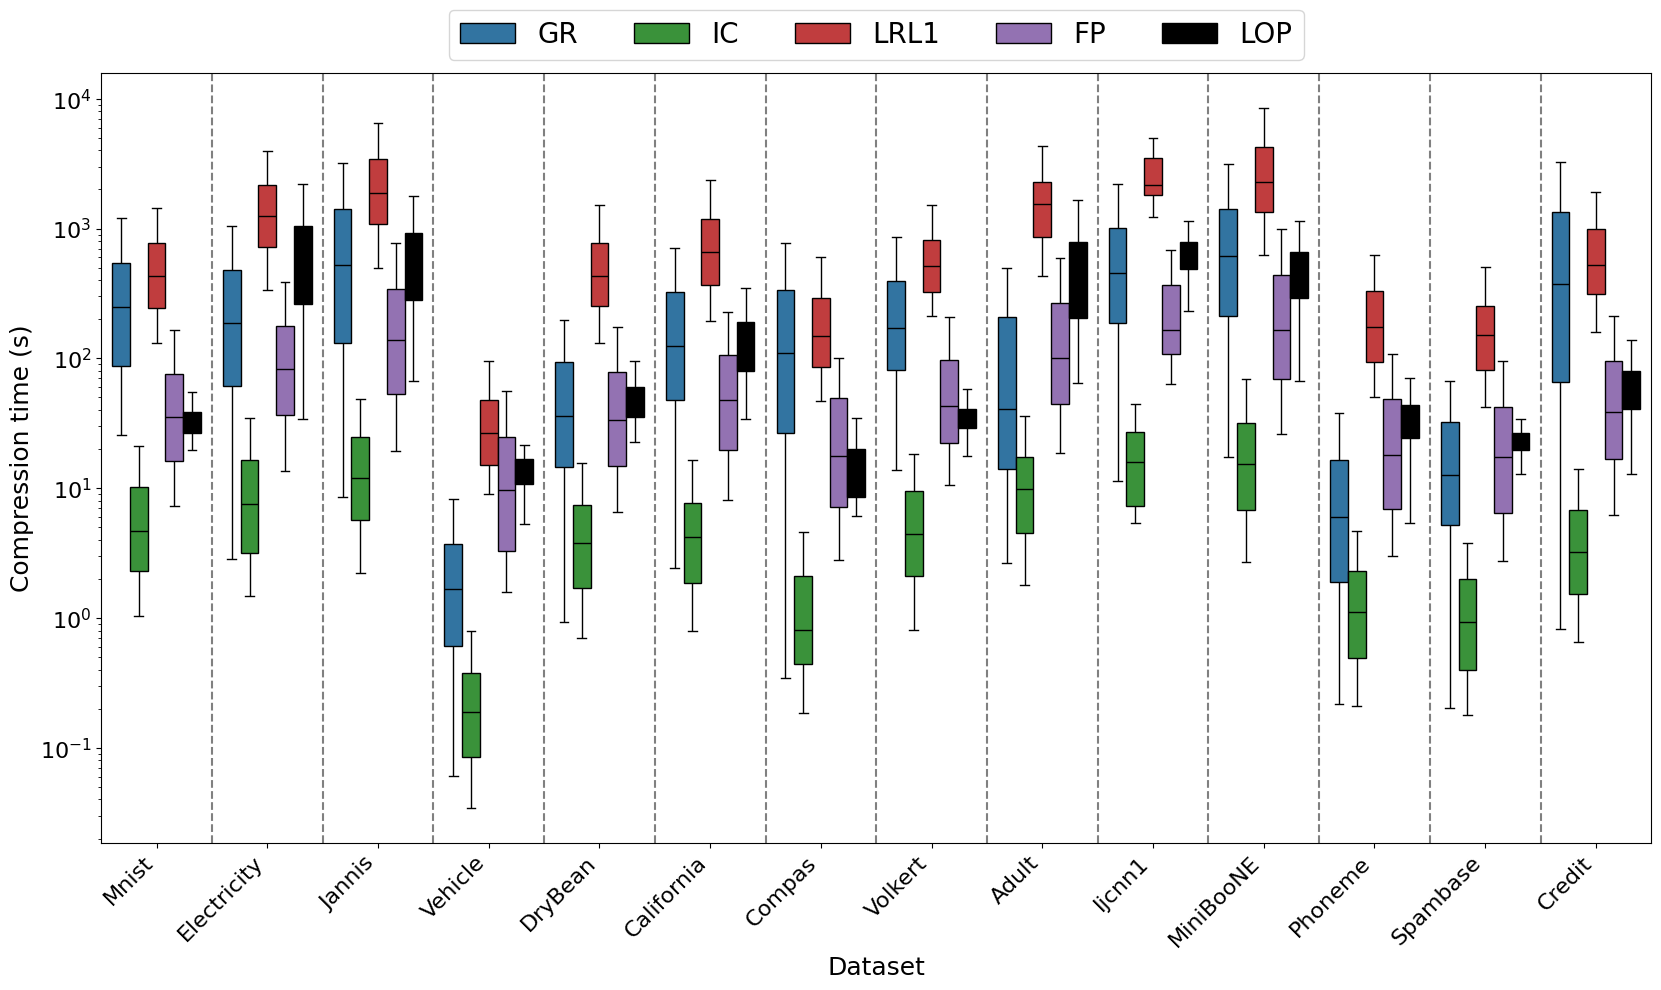

In [6]:
# Runtime analysis

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Reorder the datasets based on the order of keys in ds_names

ds_names = {
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Adult': 'Adult',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}

df = []
for d in datasets:
    keys = [k for k in results_horse_race.keys() if k.split('_')[0] == d]
    
    for i, k in enumerate(keys):
        compression_t = np.zeros(5)
        for r, refinement in enumerate(results_horse_race[k]['refinements']):
            compression_t[r] = refinement['compr_time']
            assert compression_t[r] > 0
        df.append([d] + compression_t.tolist())

df = pd.DataFrame(df, columns=['dname', 'gr', 'lrl1', 'ic', 'ours', 'forestprune'])
df = df[['dname', 'gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df.columns = ['dname', 'GR', 'IC', 'LRL1', 'FP', 'LOP']
df['dname'] = df['dname'].map(ds_names)
df['dname'] = pd.Categorical(df['dname'], categories=[ds_names[key] for key in ds_names.keys()], ordered=True)
df = df.sort_values('dname')

# Create a new DataFrame for plotting
df_melted = df.melt(id_vars=['dname'], value_vars=['GR', 'IC', 'LRL1', 'FP', 'LOP'], var_name='method', value_name='compression_time')

plt.figure(figsize=(20, 10))
ax = sns.boxplot(x='dname', y='compression_time', hue='method', data=df_melted, showfliers=False, palette={'GR': 'C0', 'IC': 'C2', 'LRL1': 'C3', 'FP': 'C4', 'LOP': 'black'})
ax.set_yscale('log')

# Add vertical lines as dividers between datasets
for i in range(len(datasets) - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--')

plt.xticks(rotation=45, ha='right', fontsize=16)  # Adjust rotation and alignment
plt.yticks(fontsize=16)
plt.ylabel('Compression time (s)', fontsize=18)
plt.xlabel('Dataset', fontsize=18)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5, fontsize=20)
plt.savefig('plots/compression_time_boxplot_xgb.pdf')

print('compression time per dataset')
print(df.groupby('dname').mean().round(2))
average_compression_time_per_method = df_melted.groupby('method')['compression_time'].mean()
print("Average compression time per method:")
print(average_compression_time_per_method.round(2))


The following block is used to verify whether LOP reduces the number of features used.

In [12]:
# Analyze feature usage reduction per dataset
feature_usage_analysis = {}

for dataset in datasets:
    feature_reductions = []
    
    # Get all keys for this dataset
    dataset_keys = [k for k in results_horse_race.keys() if k.split('_')[0] == dataset]
    
    for key in dataset_keys:
        result = results_horse_race[key]
        
        # Extract features used in original model
        original_model_json = json.loads(result['model_json'])
        original_features = set()
        
        # Correct way to extract features from XGBoost JSON format
        for tree in original_model_json['trees']:
            def extract_features_recursive(node):
                if isinstance(node, dict):
                    if 'split_type' in node and node['split_type'] == 'LtSplit':
                        if 'structure' in node and 'feat_id' in node['structure']:
                            original_features.add(node['structure']['feat_id'])
                    # Recursively check children
                    for key, value in node.items():
                        if isinstance(value, (dict, list)):
                            extract_features_recursive(value)
                elif isinstance(node, list):
                    for item in node:
                        extract_features_recursive(item)
            
            extract_features_recursive(tree)
        
        # Check feature usage in compressed models
        for refinement in result['refinements']:
            if refinement['penalty'] == 'ours':  # Focus on LOP method
                compressed_model_json = json.loads(refinement['model_json'])
                compressed_features = set()
                
                for tree in compressed_model_json['trees']:
                    def extract_features_recursive(node):
                        if isinstance(node, dict):
                            if 'split_type' in node and node['split_type'] == 'LtSplit':
                                if 'structure' in node and 'feat_id' in node['structure']:
                                    compressed_features.add(node['structure']['feat_id'])
                            # Recursively check children
                            for key, value in node.items():
                                if isinstance(value, (dict, list)):
                                    extract_features_recursive(value)
                        elif isinstance(node, list):
                            for item in node:
                                extract_features_recursive(item)
                    
                    extract_features_recursive(tree)
                
                # Calculate feature reduction
                original_count = len(original_features)
                compressed_count = len(compressed_features)
                reduction = (original_count - compressed_count) / original_count if original_count > 0 else 0
                
                feature_reductions.append({
                    'original_features': original_count,
                    'compressed_features': compressed_count,
                    'reduction_ratio': reduction
                })
    
    if feature_reductions:
        feature_usage_analysis[dataset] = {
            'avg_original_features': np.mean([x['original_features'] for x in feature_reductions]),
            'avg_compressed_features': np.mean([x['compressed_features'] for x in feature_reductions]),
            'avg_reduction_ratio': np.mean([x['reduction_ratio'] for x in feature_reductions]),
            'count': len(feature_reductions)
        }

# Display results
print("Feature Usage Analysis (LOP vs Original XGBoost)")
print("=" * 60)
print(f"{'Dataset':<20} {'Orig Feat':<12} {'Comp Feat':<12} {'Reduction %':<12}")
print("-" * 60)

for dataset in sorted(feature_usage_analysis.keys()):
    stats = feature_usage_analysis[dataset]
    print(f"{dataset:<20} {stats['avg_original_features']:<12.1f} {stats['avg_compressed_features']:<12.1f} {stats['avg_reduction_ratio']*100:<12.1f}")

# Overall average
if feature_usage_analysis:
    all_reductions = [stats['avg_reduction_ratio'] for stats in feature_usage_analysis.values()]
    all_orig_features = [stats['avg_original_features'] for stats in feature_usage_analysis.values()]
    all_comp_features = [stats['avg_compressed_features'] for stats in feature_usage_analysis.values()]

    print("-" * 60)
    print(f"{'Overall Average':<20} {np.mean(all_orig_features):<12.1f} {np.mean(all_comp_features):<12.1f} {np.mean(all_reductions)*100:<12.1f}")

Feature Usage Analysis (LOP vs Original XGBoost)
Dataset              Orig Feat    Comp Feat    Reduction % 
------------------------------------------------------------
Adult                11.8         4.5          51.3        
California           5.3          3.9          22.0        
CompasTwoYears       3.4          1.1          53.8        
Credit               6.8          1.8          64.1        
DryBean[6vRest]      8.4          2.3          65.3        
Electricity          4.4          3.7          15.2        
Ijcnn1               7.5          5.3          25.0        
Jannis               18.5         6.0          52.4        
MiniBooNE            15.4         8.2          34.9        
Mnist[2v4]           23.9         3.9          64.0        
Phoneme              4.2          3.3          21.9        
Spambase             15.7         6.4          50.2        
Vehicle              8.7          4.8          39.4        
Volkert[2v7]         20.9         4.6          64.

The following blocks check what percentage of compression comes from deleting trees and what comes from deleting subtrees

These can take a while, so skip them if you don't need them

In [7]:
import veritas
import numpy as np

# Returns two lists of models: one for XGBoost models and one for compressed models.   
def iterate_xgb_and_model(results_horse_race, method):
    xgb_models = []
    ours_models = []
    for key, data in results_horse_race.items():
        if key.split('_')[1] != '100':
            continue
        xgb_model = veritas.AddTree.from_json(data['model_json'])
        ours_model = None
        for refinement in data['refinements']:
            if refinement['penalty'] == method:
                ours_model = veritas.AddTree.from_json(refinement['model_json'])
                break
        if ours_model:
            xgb_models.append(xgb_model)
            ours_models.append(ours_model)
    return xgb_models, ours_models

models = iterate_xgb_and_model(results_horse_race, method='ours')


In [8]:
# Checks if two trees partially match, i.e., one is a compressed version of the other.
def partially_match(tree, comp_tree, node, comp_node):
    if comp_tree.is_internal(comp_node) and tree.is_internal(node):
        if comp_tree.get_split(comp_node) == tree.get_split(node):
            return partially_match(tree, comp_tree, tree.left(node), comp_tree.left(comp_node)) and \
                   partially_match(tree, comp_tree, tree.right(node), comp_tree.right(comp_node))
    elif comp_tree.is_leaf(comp_node) and tree.is_leaf(node):
        return True
    elif comp_tree.is_leaf(comp_node) and tree.is_internal(node):
        return True
    else:
        return False

# Iterate through the models and calculate some statistics
result = np.zeros((len(models[0]), 3)) # size original model, size full trees pruned, size remaining trees
for k, (model, comp_model) in enumerate(zip(*models)):
    i = 0
    result[k, 0] = model.num_leafs()  # size of original model
    for comp_t in comp_model:
        matched = False
        while matched == False:
            if partially_match(model[i], comp_t, 0, 0):
                matched = True
                result[k, 2] += comp_t.num_leaves()
                i += 1
            else:
                result[k, 1] += model[i].num_leaves()  # size full trees pruned
                i += 1

print('Compression from pruning trees: ', np.nanmean(result[:, 1]/(result[:,0]-result[:, 2])))
print('Compression from pruning subtrees: ', np.nanmean((result[:, 0] - result[:, 1] - result[:, 2])/(result[:, 0] - result[:, 2])))

Compression from pruning trees:  0.28583339593673146
Compression from pruning subtrees:  0.7141666040632686


/tmp/ipykernel_298417/4250961052.py:30: RuntimeWarning: invalid value encountered in divide
  print('Compression from pruning trees: ', np.nanmean(result[:, 1]/(result[:,0]-result[:, 2])))
/tmp/ipykernel_298417/4250961052.py:31: RuntimeWarning: invalid value encountered in divide
  print('Compression from pruning subtrees: ', np.nanmean((result[:, 0] - result[:, 1] - result[:, 2])/(result[:, 0] - result[:, 2])))


The following block visualizes how XGB performs better with more trees and deeper trees

Performance data for Adult:


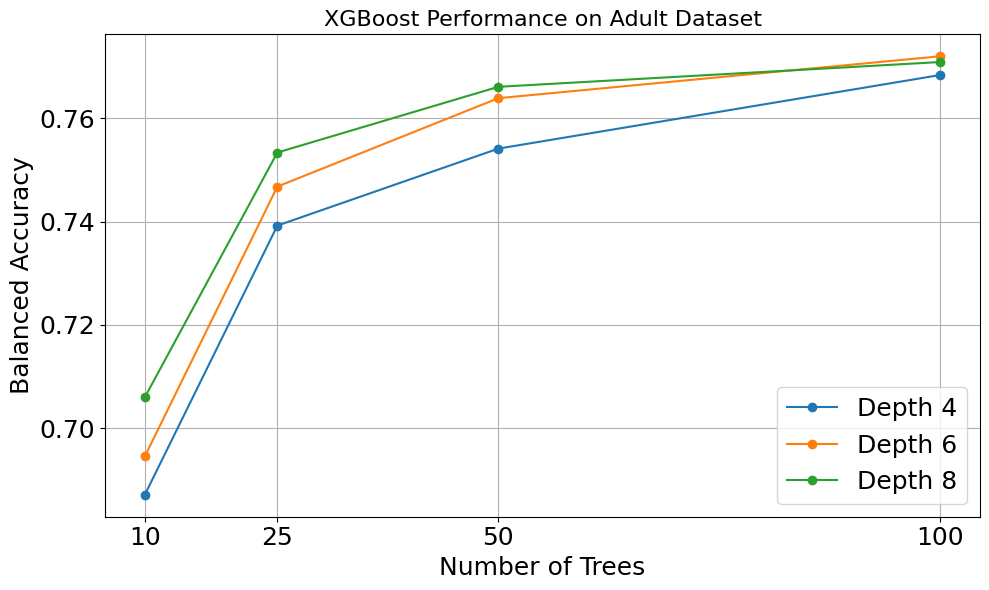

In [9]:
import matplotlib.pyplot as plt

def plot_xgb_performance(dataset_name):
    # Filter keys for the specified dataset with learning rate 0.1
    dataset_keys = [k for k in results_horse_race.keys() if k.startswith(dataset_name) and k.split('_')[3] == '0.1']

    # Extract data for plotting
    depths = sorted(set(int(k.split('_')[2]) for k in dataset_keys))  # Unique depths
    nb_trees = sorted(set(int(k.split('_')[1]) for k in dataset_keys))  # Unique number of trees

    # Prepare data for plotting
    performance_data = {depth: [] for depth in depths}
    for depth in depths:
        for trees in nb_trees:
            keys = [k for k in dataset_keys if int(k.split('_')[1]) == trees and int(k.split('_')[2]) == depth]
            avg_performance = sum(results_horse_race[k]['mtest'] for k in keys) / len(keys)
            performance_data[depth].append(avg_performance)

    # Print the data used for the plot
    print(f"Performance data for {dataset_name}:")

    # Plot the data
    plt.figure(figsize=(10, 6))
    for depth, performances in performance_data.items():
        plt.plot(nb_trees, performances, label=f'Depth {depth}', marker='o')

    plt.xlabel('Number of Trees', fontsize=18)
    plt.xticks(nb_trees, fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylabel('Balanced Accuracy', fontsize=18)
    plt.title(f'XGBoost Performance on {dataset_name} Dataset', fontsize=16)
    plt.legend(fontsize=18, loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'plots/{dataset_name.lower()}_xgb_performance.png', dpi=300)
    plt.show()

# Example usage:
plot_xgb_performance('Adult')

## Practical metrics (Table 3)

Part about the OC compression practical metrics

In [6]:
import json
results_practical_metrics = {}
datasets = set()
with open('results/xgb_verification_oc.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_practical_metrics[key] = line_dict
        datasets.add(line_dict['dname'])

In [10]:
# Print the number of times that the oc space count search runs out of resources per dataset and method
# This checks the ['oc_space'][2] value which indicates if the search ran out of resources

timeout_counts_by_method = {}

for dataset in sorted(datasets):
    timeout_counts_by_method[dataset] = {}
    
    for key, data in results_practical_metrics.items():
        if key.split('_')[0] == dataset:
            for refinement in data['refinements']:
                method = refinement['penalty']
                if method not in timeout_counts_by_method[dataset]:
                    timeout_counts_by_method[dataset][method] = {'timeouts': 0, 'total': 0}
                
                if 'oc_space' in refinement and len(refinement['oc_space']) > 2:
                    timeout_counts_by_method[dataset][method]['total'] += 1
                    if refinement['oc_space'][2] == True:  # True indicates timeout/out of resources
                        timeout_counts_by_method[dataset][method]['timeouts'] += 1

# Get all methods
all_methods = set()
for dataset_data in timeout_counts_by_method.values():
    all_methods.update(dataset_data.keys())
all_methods = sorted(all_methods)

# Print table with methods as columns
header = f"{'Dataset':<20}"
for method in all_methods:
    header += f"{method:>12}"
print(header)
print("-" * (20 + 12 * len(all_methods)))

for dataset in sorted(datasets):
    row = f"{dataset:<20}"
    for method in all_methods:
        if method in timeout_counts_by_method[dataset]:
            timeout_count = timeout_counts_by_method[dataset][method]['timeouts']
            total_count = timeout_counts_by_method[dataset][method]['total']
            percentage = (timeout_count / total_count * 100) if total_count > 0 else 0
            row += f"{timeout_count}/{total_count} ({percentage:.0f}%)".rjust(12)
        else:
            row += f"{'N/A':>12}"
    print(row)

# Print overall statistics
print("-" * (20 + 12 * len(all_methods)))
row = f"{'Overall':<20}"
method_totals = {}
for dataset_data in timeout_counts_by_method.values():
    for method, counts in dataset_data.items():
        if method not in method_totals:
            method_totals[method] = {'timeouts': 0, 'total': 0}
        method_totals[method]['timeouts'] += counts['timeouts']
        method_totals[method]['total'] += counts['total']

for method in all_methods:
    if method in method_totals:
        timeout_count = method_totals[method]['timeouts']
        total_count = method_totals[method]['total']
        percentage = (timeout_count / total_count * 100) if total_count > 0 else 0
        row += f"{timeout_count}/{total_count} ({percentage:.0f}%)".rjust(12)
    else:
        row += f"{'N/A':>12}"
print(row)

Dataset                      lop      lop-oc         xgb
--------------------------------------------------------
Adult                  0/60 (0%)   0/60 (0%) 40/60 (67%)
California            9/60 (15%)  7/60 (12%) 40/60 (67%)
CompasTwoYears         0/60 (0%)   0/60 (0%)   0/60 (0%)
Credit                 0/60 (0%)   0/60 (0%) 40/60 (67%)
DryBean[6vRest]        5/60 (8%)   5/60 (8%) 47/60 (78%)
Electricity            5/60 (8%)   5/60 (8%) 40/60 (67%)
Ijcnn1               20/60 (33%) 21/60 (35%) 50/60 (83%)
Jannis               40/60 (67%) 40/60 (67%) 55/60 (92%)
MiniBooNE            40/60 (67%) 40/60 (67%) 56/60 (93%)
Mnist[2v4]            8/60 (13%)  8/60 (13%) 53/60 (88%)
Phoneme                1/60 (2%)   1/60 (2%) 28/60 (47%)
Spambase             11/60 (18%) 11/60 (18%) 54/60 (90%)
Vehicle                5/60 (8%)   5/60 (8%) 43/60 (72%)
Volkert[2v7]         11/60 (18%)  9/60 (15%)60/60 (100%)
--------------------------------------------------------
Overall             155/840 (18

In [14]:
import numpy as np
import pandas as pd

# Print the oc_space comparison between XGBoost and compressed models per dataset
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1]

# Initialize a dictionary to store reduction factors for each method per dataset
reduction_per_dataset = {}

for dataset in datasets:
    reduction_per_method = {method: [] for method in ['lop', 'lop-oc']}
    
    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            for learning_rate in learning_rate_values:
                # Filter keys for the current combination and dataset
                keys = [
                    k for k in results_practical_metrics.keys()
                    if k.split('_')[0] == dataset and
                       k.split('_')[1] == str(n_estimators) and
                       k.split('_')[2] == str(max_depth) and
                       k.split('_')[3] == str(learning_rate)
                ]
                
                # Collect oc_space reduction factors for each method
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    xgb_oc_space = setting_data['refinements'][0]['oc_space'][0]  # XGBoost oc_space
                    
                    # Compare each refinement method to XGBoost
                    for refinement in setting_data['refinements']:
                        method = refinement['penalty']
                        if method in reduction_per_method:
                            compressed_oc_space = refinement['oc_space'][0]
                            reduction_factor = xgb_oc_space / compressed_oc_space if compressed_oc_space > 0 else 0
                            if reduction_factor >= 1:
                                reduction_per_method[method].append(reduction_factor) 
    
    reduction_per_dataset[dataset] = reduction_per_method

# Create summary table with mean values
summary_data = []
for dataset in sorted(datasets):
    row = {'Dataset': dataset}
    for method in ['lop', 'lop-oc']:
        reductions = reduction_per_dataset[dataset][method]
        if reductions:
            mean_reduction = np.mean(reductions)
            row[method] = f"{mean_reduction:.2f}"
        else:
            row[method] = "N/A"
    summary_data.append(row)

# Add overall row
overall_row = {'Dataset': 'Overall'}
for method in ['lop', 'lop-oc']:
    all_reductions = []
    for dataset_data in reduction_per_dataset.values():
        all_reductions.extend(dataset_data[method])
    if all_reductions:
        overall_mean = np.mean(all_reductions)
        overall_row[method] = f"{overall_mean:.2f}"
    else:
        overall_row[method] = "N/A"
summary_data.append(overall_row)

# Create and display DataFrame
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


        Dataset      lop   lop-oc
          Adult 11836.33  9290.89
     California   827.29   907.31
 CompasTwoYears  2432.45  2611.17
         Credit 16657.70 11187.68
DryBean[6vRest] 56264.14 70519.75
    Electricity   311.01   296.77
         Ijcnn1 25712.39 25590.99
         Jannis   556.29   568.39
      MiniBooNE  1493.53  1797.83
     Mnist[2v4] 11853.18 11616.77
        Phoneme  1628.98  1138.55
       Spambase  8778.79  8448.85
        Vehicle  7761.29  8356.52
   Volkert[2v7]  4278.50  4628.28
        Overall 11647.26 12072.27


In [15]:
import numpy as np

# Print the oc_space comparison between XGBoost and compressed models per dataset
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1]

# Initialize a dictionary to store reduction factors for each method per dataset
reduction_per_dataset = {}

for dataset in datasets:
    reduction_per_method = {method: [] for method in ['lop', 'lop-oc']}
    
    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            for learning_rate in learning_rate_values:
                # Filter keys for the current combination and dataset
                keys = [
                    k for k in results_practical_metrics.keys()
                    if k.split('_')[0] == dataset and
                       k.split('_')[1] == str(n_estimators) and
                       k.split('_')[2] == str(max_depth) and
                       k.split('_')[3] == str(learning_rate)
                ]
                
                # Collect oc_space reduction factors for each method
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    xgb_oc_space = setting_data['refinements'][0]['observed_oc_space']  # XGBoost oc_space
                    
                    # Compare each refinement method to XGBoost
                    for refinement in setting_data['refinements']:
                        method = refinement['penalty']
                        if method in reduction_per_method:
                            compressed_oc_space = refinement['observed_oc_space']
                            reduction_factor = xgb_oc_space / compressed_oc_space
                            reduction_per_method[method].append(reduction_factor)
    
    reduction_per_dataset[dataset] = reduction_per_method

# Create summary table with mean values only
summary_data = []
for dataset in sorted(datasets):
    row = {'Dataset': dataset}
    for method in ['lop', 'lop-oc']:
        reductions = reduction_per_dataset[dataset][method]
        if reductions:
            mean_reduction = np.mean(reductions)
            row[method] = f"{mean_reduction:.2f}"
        else:
            row[method] = "N/A"
    summary_data.append(row)

# Add overall row
overall_row = {'Dataset': 'Overall'}
for method in ['lop', 'lop-oc']:
    all_reductions = []
    for dataset_data in reduction_per_dataset.values():
        all_reductions.extend(dataset_data[method])
    if all_reductions:
        overall_mean = np.mean(all_reductions)
        overall_row[method] = f"{overall_mean:.2f}"
    else:
        overall_row[method] = "N/A"
summary_data.append(overall_row)

# Create and display DataFrame
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


        Dataset   lop lop-oc
          Adult 30.41  28.45
     California  7.52   8.38
 CompasTwoYears 91.84 100.85
         Credit 80.78  72.74
DryBean[6vRest] 53.48  76.42
    Electricity  8.19   8.42
         Ijcnn1 78.77  78.53
         Jannis  3.62   3.76
      MiniBooNE  3.41   3.67
     Mnist[2v4]  9.22   9.12
        Phoneme 24.01  22.78
       Spambase  4.84   4.92
        Vehicle  3.80   3.92
   Volkert[2v7]  7.91   8.15
        Overall 29.13  30.72


In [16]:
import numpy as np
import pandas as pd

# Print the verification time comparison between XGBoost and compressed models per dataset
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1]

# Initialize a dictionary to store verification times for each method per dataset
times_per_dataset = {}

for dataset in datasets:
    times_per_method = {method: [] for method in ['lop', 'lop-oc']}
    
    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            for learning_rate in learning_rate_values:
                # Filter keys for the current combination and dataset
                keys = [
                    k for k in results_practical_metrics.keys()
                    if k.split('_')[0] == dataset and
                       k.split('_')[1] == str(n_estimators) and
                       k.split('_')[2] == str(max_depth) and
                       k.split('_')[3] == str(learning_rate)
                ]
                
                # Collect verification times for each method
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    
                    # Compare each refinement method
                    for refinement in setting_data['refinements']:
                        method = refinement['penalty']
                        if method in times_per_method:
                            verification_time = refinement['verification_results']['exact_emp_rob_time']
                            times_per_method[method].append(verification_time)
    
    times_per_dataset[dataset] = times_per_method

# Create summary table with mean values
summary_data = []
for dataset in sorted(datasets):
    row = {'Dataset': dataset}
    for method in ['lop', 'lop-oc']:
        times = times_per_dataset[dataset][method]
        if times:
            mean_time = np.mean(times)
            row[method] = f"{mean_time:.2f}"
        else:
            row[method] = "N/A"
    summary_data.append(row)

# Add overall row
overall_row = {'Dataset': 'Overall'}
for method in ['lop', 'lop-oc']:
    all_times = []
    for dataset_data in times_per_dataset.values():
        all_times.extend(dataset_data[method])
    if all_times:
        overall_mean = np.mean(all_times)
        overall_row[method] = f"{overall_mean:.2f}"
    else:
        overall_row[method] = "N/A"
summary_data.append(overall_row)

# Create and display DataFrame
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


        Dataset    lop lop-oc
          Adult   3.47   3.45
     California  58.43  55.83
 CompasTwoYears   2.83   2.71
         Credit   4.66   5.56
DryBean[6vRest]  13.07  12.26
    Electricity  37.97  38.65
         Ijcnn1  24.33  25.08
         Jannis 408.49 405.68
      MiniBooNE 243.94 245.93
     Mnist[2v4]  13.64  13.64
        Phoneme  39.99  39.52
       Spambase  13.66  13.78
        Vehicle   3.17   3.03
   Volkert[2v7]  14.08  14.11
        Overall  62.98  62.80


Analyzing actual practical metrics ICML paper

In [1]:
import json
results_practical_metrics = {}
datasets = set()
with open('results/practical_metrics.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['n_estimators']}_{line_dict['depth']}_{line_dict['lr']}_{line_dict['fold']}"
        results_practical_metrics[key] = line_dict
        datasets.add(line_dict['dname'])

In [2]:
import numpy as np
# Print the time required to check empirical robustness for each refinement method
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1, 0.25, 0.5, 1.0]

# Initialize a dictionary to store medians for each refinement method
medians_per_refinement = {method: [] for method in ['xgb', 'gr', 'lrl1', 'ic', 'ours', 'forestprune']}

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for learning_rate in learning_rate_values:
            # Filter keys for the current combination
            keys = [
                k for k in results_practical_metrics.keys()
                if k.split('_')[1] == str(n_estimators) and
                   k.split('_')[2] == str(max_depth) and
                   k.split('_')[3] == str(learning_rate)
            ]
            
            # Collect verification times for each refinement method
            for method in medians_per_refinement.keys():
                verification_times = []
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    verification_times.extend(
                        refinement['verification_results']['exact_emp_rob_time']
                        for refinement in setting_data['verifications']
                        if refinement['penalty'] == method
                    )
                
                # Calculate the median for the current combination
                if verification_times:
                    medians_per_refinement[method].append(np.median(verification_times))

# Print the collected medians for each refinement method
for method, medians in medians_per_refinement.items():
    if medians:
        q25 = np.quantile(medians, 0.25)
        q50 = np.quantile(medians, 0.50)
        q75 = np.quantile(medians, 0.75)
        print(f"{method}: 25% = {q25}, 50% = {q50}, 75% = {q75}")
    else:
        print(f"No medians collected for {method}.")

xgb: 25% = 108.0604202747345, 50% = 365.4421656727791, 75% = 1044.8283877968788
gr: 25% = 20.809569269418716, 50% = 45.54278248548508, 75% = 70.06762483716011
lrl1: 25% = 64.02000698447227, 50% = 147.8472319841385, 75% = 444.7572651207447
ic: 25% = 30.494747191667557, 50% = 69.81573647260666, 75% = 133.79832690954208
ours: 25% = 9.844259947538376, 50% = 14.151219487190247, 75% = 21.92925837635994
forestprune: 25% = 16.878838151693344, 50% = 32.0611589550972, 75% = 78.9765764772892


In [3]:
import numpy as np
# Print memory usage for each refinement method
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1, 0.25, 0.5, 1.0]

# Initialize a dictionary to store medians for each refinement method
medians_per_refinement = {method: [] for method in ['xgb', 'gr', 'lrl1', 'ic', 'ours', 'forestprune']}

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for learning_rate in learning_rate_values:
            # Filter keys for the current combination
            keys = [
                k for k in results_practical_metrics.keys()
                if k.split('_')[1] == str(n_estimators) and
                   k.split('_')[2] == str(max_depth) and
                   k.split('_')[3] == str(learning_rate)
            ]
            
            # Collect verification times for each refinement method
            for method in medians_per_refinement.keys():
                memory = []
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    memory.extend(
                        refinement['memory_usage']
                        for refinement in setting_data['memory']
                        if refinement['penalty'] == method
                    )
                
                # Calculate the median for the current combination
                if memory:
                    medians_per_refinement[method].append(np.median(memory))

# Print the collected medians for each refinement method
for method, medians in medians_per_refinement.items():
    if medians:
        q25 = np.quantile(medians, 0.25)
        q50 = np.quantile(medians, 0.50)
        q75 = np.quantile(medians, 0.75)
        print(f"{method}: 25% = {q25}, 50% = {q50}, 75% = {q75}")
    else:
        print(f"No medians collected for {method}.")

xgb: 25% = 45631.25, 50% = 92300.0, 75% = 211009.375
gr: 25% = 11459.375, 50% = 22350.0, 75% = 32975.0
lrl1: 25% = 29553.125, 50% = 58812.5, 75% = 129975.0
ic: 25% = 17112.5, 50% = 28593.75, 75% = 48396.875
ours: 25% = 5621.875, 50% = 8187.5, 75% = 12021.875
forestprune: 25% = 9718.75, 50% = 15337.5, 75% = 29165.625


In [7]:
# Evaluates the number of splits that have to be evaluated after the refinement methods
import numpy as np
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1, 0.25, 0.5, 1.0]
# Initialize a dictionary to store medians for each refinement method
medians_per_refinement = {method: [] for method in ['xgb', 'gr', 'lrl1', 'ic', 'ours', 'forestprune']}
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for learning_rate in learning_rate_values:
            # Filter keys for the current combination
            keys = [
                k for k in results_practical_metrics.keys()
                if k.split('_')[1] == str(n_estimators) and
                   k.split('_')[2] == str(max_depth) and
                   k.split('_')[3] == str(learning_rate)
            ]
            
            # Collect verification times for each refinement method
            for method in medians_per_refinement.keys():
                splits = []
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    splits.extend(
                        refinement['nb_splits_done']
                        for refinement in setting_data['nb_splits']
                        if refinement['penalty'] == method
                    )
                
                # Calculate the median for the current combination
                if splits:
                    medians_per_refinement[method].append(np.median(splits))
# Print the collected medians for each refinement method
for method, medians in medians_per_refinement.items():
    if medians:
        q25 = np.quantile(medians, 0.25)
        q50 = np.quantile(medians, 0.50)
        q75 = np.quantile(medians, 0.75)
        print(f"{method}: 25% = {q25}, 50% = {q50}, 75% = {q75}")
    else:
        print(f"No medians collected for {method}.")

xgb: 25% = 94.5, 50% = 197.0, 75% = 386.125
gr: 25% = 40.5, 50% = 87.5, 75% = 148.75
lrl1: 25% = 71.875, 50% = 147.25, 75% = 226.5
ic: 25% = 37.0, 50% = 66.25, 75% = 120.0
ours: 25% = 21.125, 50% = 28.75, 75% = 35.75
forestprune: 25% = 36.75, 50% = 53.75, 75% = 101.5


In [ ]:
# Prints the exact empirical robustness of each refinement method (Table A7)
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_practical_metrics.keys() if k.split('_')[0] == d]
    exact_emp_rob = np.zeros((len(keys), 6))
    for i, k in enumerate(keys):
        verification_results = results_practical_metrics[k]['verifications']
        for r, refinement in enumerate(verification_results):
            exact_emp_rob[i, r] = refinement['verification_results']['exact_emp_rob']
    df.append(exact_emp_rob.mean(axis=0))

df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['xgb', 'gr', 'lrl1', 'ic', 'ours', 'forestprune'])
df = df[['xgb', 'gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df_horse_race_1 = df.copy()
df_horse_race = df_horse_race_1.round(3)
df_horse_race = df_horse_race.style.format(decimal='.', precision=3)
df_horse_race = df_horse_race.to_latex()
print(df_horse_race)

\begin{tabular}{lrrrrrr}
 & xgb & gr & ic & lrl1 & forestprune & ours \\
Spambase & 0.091 & 0.091 & 0.100 & 0.087 & 0.114 & 0.120 \\
Phoneme & 0.098 & 0.088 & 0.109 & 0.081 & 0.106 & 0.103 \\
CompasTwoYears & 0.050 & 0.165 & 0.076 & 0.055 & 0.175 & 0.170 \\
Electricity & 0.043 & 0.031 & 0.041 & 0.039 & 0.035 & 0.048 \\
Credit & 0.112 & 0.275 & 0.207 & 0.132 & 0.283 & 0.301 \\
Ijcnn1 & 0.224 & 0.197 & 0.230 & 0.216 & 0.224 & 0.226 \\
Volkert[2v7] & 0.164 & 0.187 & 0.196 & 0.178 & 0.198 & 0.197 \\
MiniBooNE & 0.114 & 0.122 & 0.128 & 0.123 & 0.121 & 0.134 \\
Jannis & 0.067 & 0.097 & 0.098 & 0.079 & 0.096 & 0.108 \\
Mnist[2v4] & 0.194 & 0.195 & 0.214 & 0.180 & 0.221 & 0.221 \\
California & 0.079 & 0.078 & 0.083 & 0.077 & 0.080 & 0.092 \\
Vehicle & 0.145 & 0.147 & 0.158 & 0.138 & 0.155 & 0.162 \\
Adult & 0.348 & 0.338 & 0.410 & 0.341 & 0.449 & 0.469 \\
DryBean[6vRest] & 0.181 & 0.182 & 0.209 & 0.176 & 0.219 & 0.215 \\
average & 0.136 & 0.157 & 0.161 & 0.136 & 0.177 & 0.183 \\
\end{tabular}


## RandomForest binary classification

In [20]:
import json
results_rf_classification = {}
datasets = set()
with open('results/rf_classification.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['fold']}"
        results_rf_classification[key] = line_dict
        datasets.add(line_dict['dname'])

In [29]:
# Compression ratios
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_rf_classification.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys),6))
    for i, k in enumerate(keys):
        n_leafs_orig = results_rf_classification[k]['nleafs']
        compression_f[i, 5] = n_leafs_orig
        for r, refinement in enumerate(results_rf_classification[k]['refinements']):
            try:
                compression_f[i, r] = n_leafs_orig/refinement['nleafs']
            except ZeroDivisionError: # Forestprune can prune away to 0 leafs if the original model has a validation accuracy of 0.5
                compression_f[i, r] = n_leafs_orig
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'ic', 'lrl1', 'ours', 'forestprune', 'nleafs'])
df = df[['nleafs','gr',  'ic', 'lrl1', 'forestprune', 'ours', ]]
df_rf_classification = df.copy()
df_rf_classification = df_rf_classification.round(1)
df_rf_classification = df_rf_classification.style.format(decimal='.', precision=1)
df_rf_classification = df_rf_classification.to_latex()
print(df_rf_classification)


\begin{tabular}{lrrrrrr}
 & nleafs & gr & ic & lrl1 & forestprune & ours \\
DryBean[6vRest] & 26042.8 & 16.7 & 16.9 & 1.2 & 202.0 & 66.6 \\
Vehicle & 5111.0 & 7.7 & 16.9 & 1.0 & 12.8 & 46.4 \\
Volkert[2v7] & 25773.5 & 90.3 & 31.5 & 9.0 & 38.1 & 110.9 \\
Spambase & 18634.6 & 44.5 & 23.5 & 1.3 & 32.5 & 106.7 \\
MiniBooNE & 149448.7 & 132.5 & 14.1 & 5.0 & 8.5 & 121.4 \\
Phoneme & 31578.2 & 8.0 & 12.5 & 2.0 & 15.9 & 23.7 \\
California & 89481.1 & 174.4 & 22.5 & 1.7 & 13.0 & 196.2 \\
Jannis & 183003.7 & 158.8 & 6.5 & 2.1 & 3.7 & 249.0 \\
Mnist[2v4] & 20039.0 & 61.9 & 22.7 & 2.4 & 22.5 & 74.1 \\
Electricity & 135271.6 & 114.4 & 21.9 & 7.8 & 19.5 & 125.0 \\
Adult & 99148.2 & 194.6 & 90.9 & 11.0 & 322.6 & 1046.8 \\
Credit & 91428.9 & 216.9 & 9.1 & 1.0 & 26.9 & 1859.5 \\
Ijcnn1 & 131413.7 & 199.6 & 80.0 & 3.0 & 59.0 & 227.9 \\
CompasTwoYears & 68893.7 & 473.7 & 15.3 & 1.0 & 8998.6 & 12086.8 \\
average & 76804.9 & 135.3 & 27.5 & 3.5 & 698.3 & 1167.2 \\
\end{tabular}



In [ ]:
# Tree reduction factors
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_rf_classification.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys),6))
    for i, k in enumerate(keys):
        n_leafs_orig = results_rf_classification[k]['ntrees']
        compression_f[i, 5] = n_leafs_orig
        for r, refinement in enumerate(results_rf_classification[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['ntrees']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'ic', 'lrl1', 'ours', 'forestprune', 'ntrees'])
df = df[['ntrees','gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df_rf_classification = df.copy()
df_rf_classification = df_rf_classification.round(1)
df_rf_classification = df_rf_classification.style.format(decimal='.', precision=1)
df_rf_classification = df_rf_classification.to_latex()
print(df_rf_classification)


\begin{tabular}{lrrrrrr}
 & ntrees & gr & ic & lrl1 & forestprune & ours \\
Phoneme & 133.3 & 1.0 & 13.3 & 2.0 & 14.3 & 6.8 \\
Credit & 133.3 & 1.0 & 9.8 & 1.0 & 8.0 & 11.5 \\
Mnist[2v4] & 133.3 & 1.0 & 23.2 & 2.4 & 20.7 & 15.1 \\
Ijcnn1 & 133.3 & 1.0 & 77.9 & 3.0 & 49.3 & 29.7 \\
California & 133.3 & 1.0 & 22.3 & 1.8 & 12.7 & 16.5 \\
MiniBooNE & 133.3 & 1.0 & 14.8 & 5.1 & 8.4 & 9.2 \\
Spambase & 133.3 & 1.0 & 24.3 & 1.3 & 29.6 & 21.7 \\
Adult & 133.3 & 1.0 & 96.6 & 12.1 & 47.8 & 17.4 \\
Jannis & 133.3 & 1.0 & 7.1 & 2.2 & 3.7 & 5.5 \\
Vehicle & 133.3 & 1.0 & 16.5 & 1.0 & 11.0 & 14.2 \\
Volkert[2v7] & 133.3 & 1.0 & 33.5 & 9.3 & 29.6 & 20.6 \\
Electricity & 133.3 & 1.0 & 23.1 & 8.2 & 18.8 & 20.4 \\
CompasTwoYears & 133.3 & 1.0 & 15.5 & 1.0 & 80.1 & 46.9 \\
DryBean[6vRest] & 133.3 & 1.0 & 18.6 & 1.2 & 33.3 & 14.4 \\
average & 133.3 & 1.0 & 28.3 & 3.7 & 26.2 & 17.8 \\
\end{tabular}



In [6]:
# Drop in balanced accuracy on test set
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_rf_classification.keys() if k.split('_')[0] == d]
    mtest = np.zeros((len(keys), 6))
    for i, k in enumerate(keys):
        mtest_orig = results_rf_classification[k]['mtest']
        mtest[i, 5] = mtest_orig
        for r, refinement in enumerate(results_rf_classification[k]['refinements']):
            mtest[i, r] = mtest_orig - refinement['mtest']
    df.append(mtest.mean(axis=0)*100)


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'ic', 'lrl1', 'ours', 'forestprune', 'nleafs'])
df = df[['nleafs','gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df_rf_classification = df.copy()
df_rf_classification = df_rf_classification.round(1)
df_rf_classification = df_rf_classification.style.format(decimal='.', precision=1)
df_rf_classification = df_rf_classification.to_latex()
print(df_rf_classification)

\begin{tabular}{lrrrrrr}
 & nleafs & gr & ic & lrl1 & forestprune & ours \\
Phoneme & 87.0 & 0.3 & 0.8 & -0.0 & 1.1 & 2.2 \\
Credit & 77.5 & 0.3 & 0.7 & 0.0 & 0.5 & 0.7 \\
Mnist[2v4] & 99.3 & 0.5 & 0.4 & 0.3 & 0.6 & 0.8 \\
Ijcnn1 & 89.8 & -0.1 & -0.2 & -4.2 & -0.6 & 0.4 \\
California & 88.4 & 0.4 & 0.6 & -0.1 & 0.5 & 0.5 \\
MiniBooNE & 92.6 & 0.5 & 0.6 & -0.1 & 0.5 & 0.7 \\
Spambase & 93.4 & 0.1 & 0.9 & -0.0 & 1.1 & 0.8 \\
Adult & 75.2 & -0.6 & -0.3 & -0.4 & 0.1 & 0.0 \\
Jannis & 77.5 & 0.5 & 0.5 & 0.1 & 0.3 & 0.5 \\
Vehicle & 94.9 & -0.1 & 1.2 & 0.5 & 0.7 & 1.3 \\
Volkert[2v7] & 98.4 & 0.5 & 0.4 & 0.3 & 0.5 & 0.6 \\
Electricity & 85.3 & 0.2 & 0.3 & -0.6 & 0.6 & 0.5 \\
CompasTwoYears & 63.3 & -1.4 & 0.5 & 0.3 & -0.7 & -1.3 \\
DryBean[6vRest] & 91.5 & 0.4 & 0.4 & 0.1 & 0.6 & 0.9 \\
average & 86.7 & 0.1 & 0.5 & -0.3 & 0.4 & 0.6 \\
\end{tabular}



In [ ]:
# Plots which methods timed out on which settings
import pandas as pd
from collections import defaultdict

timeout_records = defaultdict(lambda: defaultdict(list))

for k, result in results_rf_classification.items():
    dname = k.split('_')[0]
    n_estimators = result.get('ntrees', None)
    max_depth = result.get('max_depth', None)
    setting = (n_estimators, max_depth)
    
    for refinement in result['refinements']:
        penalty = refinement['penalty']
        if refinement['compr_time'] > 21600: # 6 hours
            timeout_records[dname][setting].append(penalty)

# Build table
rows = []
for dname in sorted(timeout_records):
    for setting, methods in timeout_records[dname].items():
        rows.append({
            'dataset': dname,
            'n_estimators': setting[0],
            'max_depth': setting[1],
            'timed_out_methods': ', '.join(sorted(methods))
        })

df_timeouts = pd.DataFrame(rows)
df_timeouts = df_timeouts.sort_values(by=['dataset', 'n_estimators', 'max_depth'])

print(df_timeouts)

# Optional: export to LaTeX
print(df_timeouts.to_latex(index=False))


     dataset  n_estimators  max_depth  \
0      Adult           250         15   
1     Ijcnn1           100         15   
2     Ijcnn1           250         10   
3     Ijcnn1           250         15   
4     Jannis           250         15   
5  MiniBooNE           250         10   
6  MiniBooNE           250         15   

                                  timed_out_methods  
0                                            gr, gr  
1                      lrl1, lrl1, lrl1, lrl1, lrl1  
2              gr, gr, lrl1, lrl1, lrl1, lrl1, lrl1  
3      gr, gr, gr, gr, lrl1, lrl1, lrl1, lrl1, lrl1  
4                      lrl1, lrl1, lrl1, lrl1, lrl1  
5                            lrl1, lrl1, lrl1, lrl1  
6  gr, gr, gr, gr, gr, lrl1, lrl1, lrl1, lrl1, lrl1  
\begin{tabular}{lrrl}
\toprule
dataset & n_estimators & max_depth & timed_out_methods \\
\midrule
Adult & 250 & 15 & gr, gr \\
Ijcnn1 & 100 & 15 & lrl1, lrl1, lrl1, lrl1, lrl1 \\
Ijcnn1 & 250 & 10 & gr, gr, lrl1, lrl1, lrl1, lrl1, lrl1 \\


In [21]:
# Print compression time per dataset
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_rf_classification.keys() if k.split('_')[0] == d]
    compression_t = np.zeros((len(keys), 5))
    for i, k in enumerate(keys):
        for r, refinement in enumerate(results_rf_classification[k]['refinements']):
            compression_t[i, r] = refinement['compr_time']
    df.append(compression_t.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'ic', 'lrl1', 'ours', 'forestprune'])
df = df[['gr', 'ic',  'lrl1', 'forestprune', 'ours']]
df_rf_classification = df.copy()
df_rf_classification = df_rf_classification.round(4)
df_rf_classification = df_rf_classification.style.format(decimal='.', precision=4)
df_rf_classification = df_rf_classification.to_latex()
print(df_rf_classification)

\begin{tabular}{lrrrrr}
 & gr & ic & lrl1 & forestprune & ours \\
Volkert[2v7] & 1748.9448 & 13.5761 & 1278.4614 & 157.7182 & 52.7664 \\
Credit & 1632.5126 & 7.9508 & 2161.7506 & 106.0059 & 439.5449 \\
Electricity & 4023.8564 & 18.5983 & 6229.2547 & 364.6074 & 649.2660 \\
California & 1512.3687 & 9.6862 & 2659.2745 & 121.8197 & 194.7038 \\
CompasTwoYears & 409.6173 & 2.3639 & 595.8812 & 63.3284 & 15.4114 \\
Ijcnn1 & 10472.6787 & 65.1740 & 17136.1571 & 905.6646 & 907.5175 \\
Adult & 9727.6362 & 22.1197 & 6538.6025 & 359.8340 & 421.2261 \\
MiniBooNE & 8566.1103 & 54.0667 & 13678.6425 & 767.2930 & 1185.7958 \\
DryBean[6vRest] & 399.8267 & 6.7397 & 823.6311 & 79.2419 & 76.2328 \\
Jannis & 5998.1895 & 30.2727 & 10028.3618 & 382.8414 & 2018.9291 \\
Vehicle & 11.5031 & 0.3610 & 29.2631 & 19.3414 & 11.2084 \\
Mnist[2v4] & 2778.2036 & 10.1396 & 801.5249 & 94.1653 & 46.0771 \\
Spambase & 253.8365 & 2.0093 & 233.8212 & 39.0087 & 20.5256 \\
Phoneme & 122.1353 & 2.3563 & 398.3359 & 43.8592 & 47.983

compression time per dataset
                   GR     IC      LRL1      FP      LOP
dname                                                  
Mnist         2778.20  10.14    801.52   94.17    46.08
Electricity   4023.86  18.60   6229.25  364.61   649.27
Jannis        5998.19  30.27  10028.36  382.84  2018.93
Vehicle         11.50   0.36     29.26   19.34    11.21
DryBean        399.83   6.74    823.63   79.24    76.23
California    1512.37   9.69   2659.27  121.82   194.70
Compas         409.62   2.36    595.88   63.33    15.41
Volkert       1748.94  13.58   1278.46  157.72    52.77
Adult         9727.64  22.12   6538.60  359.83   421.23
Ijcnn1       10472.68  65.17  17136.16  905.66   907.52
MiniBooNE     8566.11  54.07  13678.64  767.29  1185.80
Phoneme        122.14   2.36    398.34   43.86    47.98
Spambase       253.84   2.01    233.82   39.01    20.53
Credit        1632.51   7.95   2161.75  106.01   439.54
Average compression time per method:
method
FP       250.34
GR      3404.10

/tmp/ipykernel_16658/1309695919.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('dname').mean().round(2))


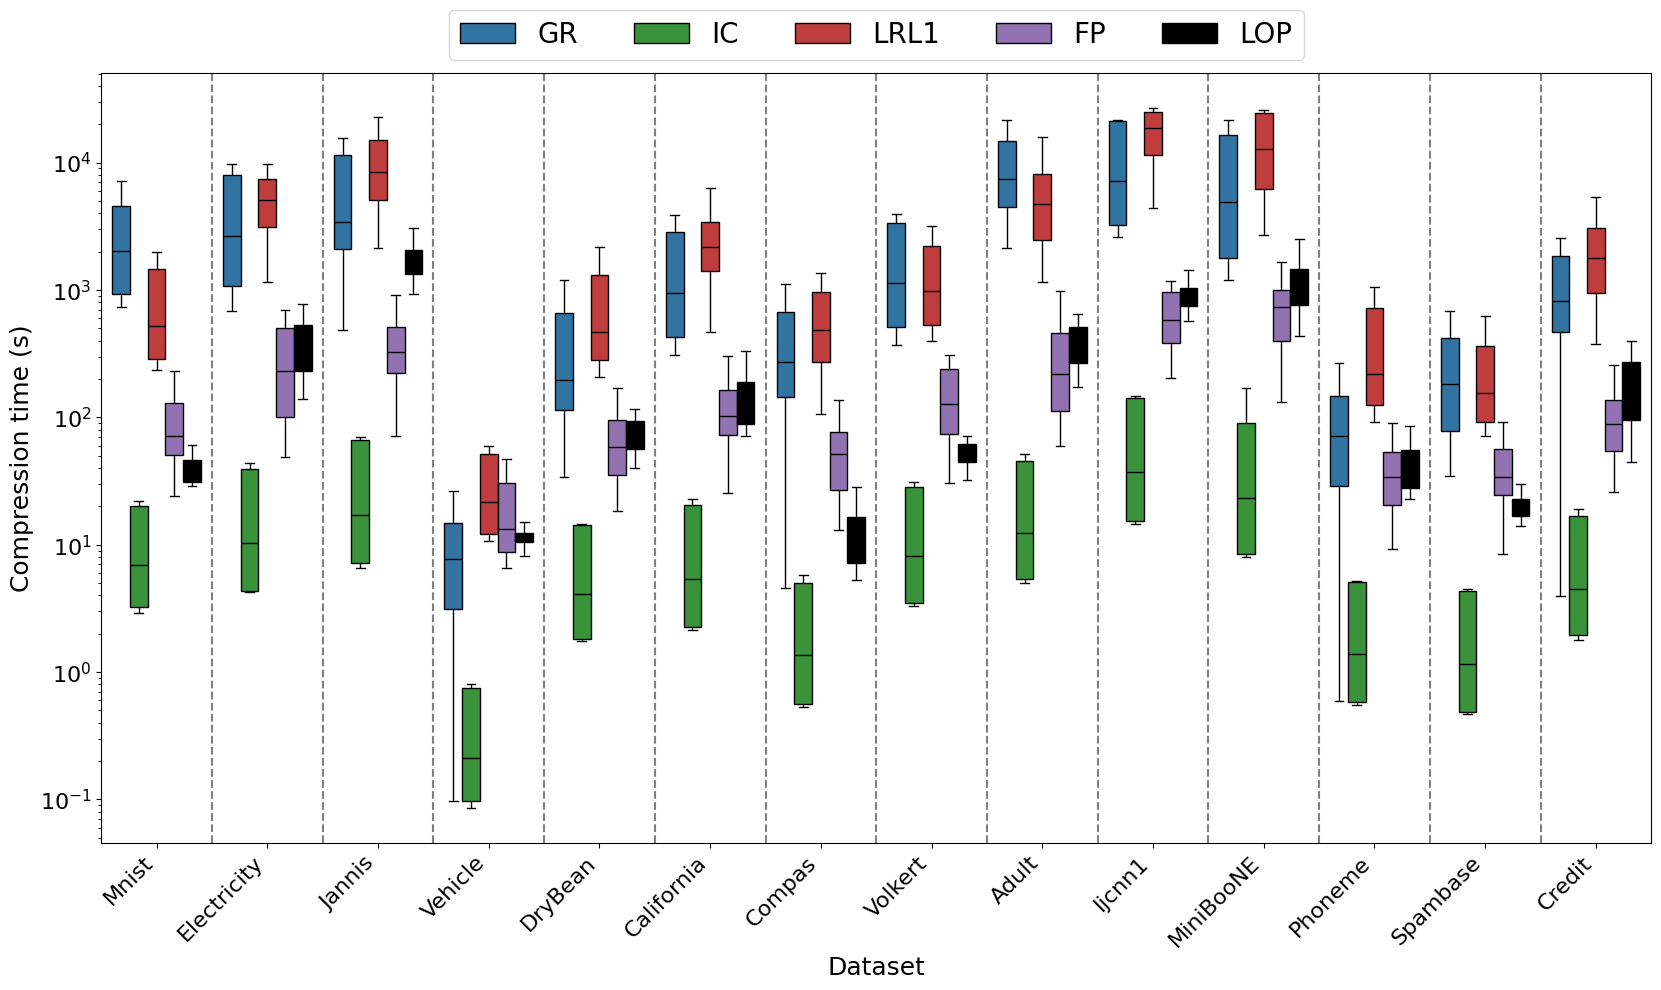

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Reorder the datasets based on the order of keys in ds_names

ds_names = {
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Adult': 'Adult',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}

df = []
for d in datasets:
    keys = [k for k in results_rf_classification.keys() if k.split('_')[0] == d]
    
    for i, k in enumerate(keys):
        compression_t = np.zeros(5)
        for r, refinement in enumerate(results_rf_classification[k]['refinements']):
            compression_t[r] = refinement['compr_time']
            assert compression_t[r] > 0
        df.append([d] + compression_t.tolist())

df = pd.DataFrame(df, columns=['dname', 'gr', 'ic', 'lrl1', 'ours', 'forestprune'])
df = df[['dname', 'gr', 'ic', 'lrl1', 'forestprune', 'ours']]
df.columns = ['dname', 'GR', 'IC', 'LRL1', 'FP', 'LOP']
df['dname'] = df['dname'].map(ds_names)
df['dname'] = pd.Categorical(df['dname'], categories=[ds_names[key] for key in ds_names.keys()], ordered=True)
df = df.sort_values('dname')

# Create a new DataFrame for plotting
df_melted = df.melt(id_vars=['dname'], value_vars=['GR', 'IC', 'LRL1', 'FP', 'LOP'], var_name='method', value_name='compression_time')

plt.figure(figsize=(20, 10))
ax = sns.boxplot(x='dname', y='compression_time', hue='method', data=df_melted, showfliers=False, palette={'GR': 'C0', 'IC': 'C2', 'LRL1': 'C3', 'FP': 'C4', 'LOP': 'black'})
ax.set_yscale('log')

# Add vertical lines as dividers between datasets
for i in range(len(datasets) - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--')

plt.xticks(rotation=45, ha='right', fontsize=16)  # Adjust rotation and alignment
plt.yticks(fontsize=16)
plt.ylabel('Compression time (s)', fontsize=18)
plt.xlabel('Dataset', fontsize=18)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5, fontsize=20)
plt.savefig('plots/compression_time_boxplot_rf.pdf')

print('compression time per dataset')
print(df.groupby('dname').mean().round(2))
average_compression_time_per_method = df_melted.groupby('method')['compression_time'].mean()
print("Average compression time per method:")
print(average_compression_time_per_method.round(2))

## XGBoost regression

In [5]:
import json
results_xgb_regression = {}
datasets = set()
with open('results/xgb_regression.txt', 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_xgb_regression[key] = line_dict
        datasets.add(line_dict['dname'])


datasets = list(datasets)

In [10]:
# Print dataset statistics
import os
os.environ['PRADA_DATA_DIR']='/cw/dtaijupiter/NoCsBack/dtai/timo/prada_data'
import prada

for dataset in datasets:
    data = prada.get_dataset(dataset)
    data.load_dataset()
    nb_examples, nb_features = data.X.shape
    print(f"Dataset: {dataset}, Number of Examples: {nb_examples}, Number of Features: {nb_features}")


loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/House16H.h5
Dataset: House16H, Number of Examples: 22784, Number of Features: 16
loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/Ailerons.h5
Dataset: Ailerons, Number of Examples: 13750, Number of Features: 33
loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/CpuSmall.h5
Dataset: CpuSmall, Number of Examples: 8192, Number of Features: 12
loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/Houses.h5
Dataset: Houses, Number of Examples: 20640, Number of Features: 8
loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/Elevators.h5
Dataset: Elevators, Number of Examples: 16599, Number of Features: 16
loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/WineQuality.h5
Dataset: WineQuality, Number of Examples: 6497, Number of Features: 11
loading cached /cw/dtaijupiter/NoCsBack/dtai/timo/prada_data/Abalone.h5
Dataset: Abalone, Number of Examples: 4177, Number of Features: 8


In [11]:
# Print compression ratios
import numpy as np
import pandas as pd

df = []
for d in datasets:
    keys = [k for k in results_xgb_regression.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys), 5))
    avg_n_leafs = np.zeros(len(keys))
    for i, k in enumerate(keys):
        n_leafs_orig = results_xgb_regression[k]['nleafs']
        compression_f[i, 4] = n_leafs_orig
        for r, refinement in enumerate(results_xgb_regression[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['nleafs']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'nleafs'])
df = df[['nleafs', 'gr', 'lrl1', 'forestprune', 'ours']]
df_xgb_regression = df.copy()
df_xgb_regression = df_xgb_regression.round(1)
df_xgb_regression = df_xgb_regression.style.format(decimal='.', precision=1)
df_xgb_regression = df_xgb_regression.to_latex()
print(df_xgb_regression)

\begin{tabular}{lrrrrr}
 & nleafs & gr & lrl1 & forestprune & ours \\
House16H & 3783.3 & 16.6 & 1.6 & 82.4 & 233.8 \\
Ailerons & 3406.3 & 11.1 & 1.3 & 12.9 & 35.2 \\
CpuSmall & 2803.3 & 4.8 & 1.5 & 1.8 & 29.2 \\
Houses & 3810.4 & 8.4 & 1.3 & 6.9 & 19.6 \\
Elevators & 3795.2 & 8.4 & 1.2 & 2.2 & 21.6 \\
WineQuality & 2969.0 & 16.8 & 1.3 & 71.6 & 234.6 \\
Abalone & 2557.6 & 28.6 & 1.4 & 178.3 & 120.4 \\
average & 3303.6 & 13.5 & 1.4 & 50.9 & 99.2 \\
\end{tabular}



In [4]:
# Tree reduction factors
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_xgb_regression.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys),5))
    for i, k in enumerate(keys):
        n_leafs_orig = results_xgb_regression[k]['ntrees']
        compression_f[i, 4] = n_leafs_orig
        for r, refinement in enumerate(results_xgb_regression[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['ntrees']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'ntrees'])
df = df[['ntrees', 'gr', 'lrl1', 'forestprune', 'ours']]
df_xgb_regression = df.copy()
df_xgb_regression = df_xgb_regression.round(1)
df_xgb_regression = df_xgb_regression.style.format(decimal='.', precision=1)
df_xgb_regression = df_xgb_regression.to_latex()
print(df_xgb_regression)

\begin{tabular}{lrrrrr}
 & ntrees & gr & lrl1 & forestprune & ours \\
CpuSmall & 46.2 & 1.0 & 1.5 & 1.0 & 9.5 \\
Houses & 46.2 & 1.0 & 1.3 & 3.4 & 6.5 \\
WineQuality & 46.2 & 1.0 & 1.4 & 11.7 & 15.3 \\
Elevators & 46.2 & 1.0 & 1.2 & 1.3 & 6.2 \\
Abalone & 46.2 & 1.0 & 1.5 & 11.2 & 25.9 \\
House16H & 46.2 & 1.0 & 1.6 & 12.5 & 16.2 \\
Ailerons & 46.2 & 1.0 & 1.4 & 4.6 & 12.7 \\
average & 46.2 & 1.0 & 1.4 & 6.5 & 13.2 \\
\end{tabular}



In [5]:
# Print RMSE
df = []
for d in datasets:
    keys = [k for k in results_xgb_regression.keys() if k.split('_')[0] == d]
    performance_diff = np.zeros((len(keys), 5))
    for i, k in enumerate(keys):
        orig_performance = results_xgb_regression[k]['mtest']
        performance_diff[i, 4] = orig_performance
        for r, refinement in enumerate(results_xgb_regression[k]['refinements']):
            performance_diff[i, r] = refinement['mtest']
    df.append(performance_diff.mean(axis=0))

df.append(np.array(df).mean(axis=0))
df = np.array(df)
df = pd.DataFrame(df, index= datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'xgb'])
df_xgb_regression = df[['xgb', 'gr', 'lrl1', 'forestprune', 'ours']]
df_xgb_regression = df_xgb_regression.round(3)
df_xgb_regression = df_xgb_regression.style.format(decimal='.', precision=3)
df_xgb_regression = df_xgb_regression.to_latex()
print(df_xgb_regression)

\begin{tabular}{lrrrrr}
 & xgb & gr & lrl1 & forestprune & ours \\
CpuSmall & 0.141 & 0.132 & 0.129 & 0.140 & 0.140 \\
Houses & 0.173 & 0.173 & 0.167 & 0.175 & 0.176 \\
WineQuality & 0.352 & 0.353 & 0.355 & 0.351 & 0.358 \\
Elevators & 0.213 & 0.207 & 0.202 & 0.213 & 0.219 \\
Abalone & 0.298 & 0.297 & 0.308 & 0.303 & 0.293 \\
House16H & 0.330 & 0.335 & 0.327 & 0.339 & 0.343 \\
Ailerons & 0.202 & 0.200 & 0.196 & 0.202 & 0.205 \\
average & 0.244 & 0.243 & 0.240 & 0.246 & 0.248 \\
\end{tabular}



In [6]:
# Print RMSE
df = []
for d in datasets:
    keys = [k for k in results_xgb_regression.keys() if k.split('_')[0] == d and k.split('_')[3] == '0.1']
    performance_diff = np.zeros((len(keys), 5))
    for i, k in enumerate(keys):
        orig_performance = results_xgb_regression[k]['mtest']
        performance_diff[i, 4] = orig_performance
        for r, refinement in enumerate(results_xgb_regression[k]['refinements']):
            performance_diff[i, r] = refinement['compr_time']
    df.append(performance_diff.mean(axis=0))

df.append(np.array(df).mean(axis=0))
df = np.array(df)
df = pd.DataFrame(df, index= datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'xgb'])
df_xgb_regression = df[['xgb', 'gr', 'lrl1', 'forestprune', 'ours']]
df_xgb_regression = df_xgb_regression.round(3)
df_xgb_regression = df_xgb_regression.style.format(decimal='.', precision=3)
df_xgb_regression = df_xgb_regression.to_latex()
print(df_xgb_regression)

\begin{tabular}{lrrrrr}
 & xgb & gr & lrl1 & forestprune & ours \\
Houses & 0.183 & 346.263 & 478.727 & 40.806 & 4367.061 \\
House16H & 0.316 & 267.494 & 499.192 & 42.474 & 1642.480 \\
Elevators & 0.226 & 307.043 & 436.522 & 37.951 & 1993.976 \\
WineQuality & 0.341 & 41.600 & 185.468 & 24.590 & 1407.261 \\
Ailerons & 0.202 & 118.122 & 423.545 & 36.796 & 4480.573 \\
CpuSmall & 0.167 & 36.308 & 216.085 & 23.620 & 1404.237 \\
Abalone & 0.281 & 102.288 & 120.264 & 20.327 & 72.351 \\
average & 0.245 & 174.160 & 337.115 & 32.366 & 2195.420 \\
\end{tabular}



## RandomForest regression

In [11]:
import json
results_rf_regression = {}
datasets = set()
with open('results/rf_regression.txt', 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['fold']}"
        results_rf_regression[key] = line_dict
        datasets.add(line_dict['dname'])


datasets = list(datasets)

In [26]:
import numpy as np
import pandas as pd
datasets = list(datasets)
df = []
for d in datasets:
    keys = [k for k in results_rf_regression.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys),5))
    for i, k in enumerate(keys):
        n_leafs_orig = results_rf_regression[k]['ntrees']
        compression_f[i, 4] = n_leafs_orig
        for r, refinement in enumerate(results_rf_regression[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['ntrees']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'ntrees'])
df = df[['ntrees', 'gr', 'lrl1', 'forestprune', 'ours']]
df_rf_regression = df.copy()
df_rf_regression = df_rf_regression.round(1)
df_rf_regression = df_rf_regression.style.format(decimal='.', precision=1)
df_rf_regression = df_rf_regression.to_latex()
print(df_rf_regression)

\begin{tabular}{lrrrrr}
 & ntrees & gr & lrl1 & forestprune & ours \\
Ailerons & 133.3 & 1.0 & 1.0 & 6.2 & 5.5 \\
WineQuality & 133.3 & 1.0 & 2.4 & 5.6 & 4.8 \\
Elevators & 133.3 & 1.0 & 2.9 & 7.5 & 7.3 \\
Houses & 133.3 & 1.0 & 4.2 & 12.0 & 9.9 \\
Abalone & 133.3 & 1.0 & 1.0 & 2.9 & 6.4 \\
CpuSmall & 133.3 & 1.0 & 1.0 & 8.4 & 6.6 \\
House16H & 133.3 & 1.0 & 5.6 & 3.7 & 9.0 \\
average & 133.3 & 1.0 & 2.6 & 6.6 & 7.1 \\
\end{tabular}



In [43]:
import numpy as np
import pandas as pd

df = []
for d in datasets:
    keys = [k for k in results_rf_regression.keys() if k.split('_')[0] == d]
    compression_f = np.zeros((len(keys), 5))
    avg_n_leafs = np.zeros(len(keys))
    for i, k in enumerate(keys):
        n_leafs_orig = results_rf_regression[k]['nleafs']
        compression_f[i, 4] = n_leafs_orig
        for r, refinement in enumerate(results_rf_regression[k]['refinements']):
            compression_f[i, r] = n_leafs_orig/refinement['nleafs']
            assert compression_f[i, r] >= 1
    df.append(compression_f.mean(axis=0))


df.append(np.array(df).mean(axis=0))
df = np.array(df)

df = pd.DataFrame(df, index=datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'nleafs'])
df = df[['nleafs', 'gr', 'lrl1', 'forestprune', 'ours']]
df_rf_regression = df.copy()
df_rf_regression = df_rf_regression.round(1)
df_rf_regression = df_rf_regression.style.format(decimal='.', precision=1)
df_rf_regression = df_rf_regression.to_latex()
print(df_rf_regression)

\begin{tabular}{lrrrrr}
 & nleafs & gr & lrl1 & forestprune & ours \\
Abalone & 79168.6 & 19.8 & 1.0 & 35.3 & 744.6 \\
CpuSmall & 118589.5 & 1.6 & 1.0 & 8.3 & 10.1 \\
WineQuality & 62076.9 & 6.0 & 2.4 & 5.3 & 5.8 \\
Ailerons & 184674.7 & 2.2 & 1.0 & 6.2 & 7.7 \\
Elevators & 189162.0 & 93.9 & 2.9 & 7.4 & 23.6 \\
House16H & 200964.8 & 105.6 & 5.3 & 3.7 & 492.5 \\
Houses & 300815.2 & 81.9 & 4.2 & 12.0 & 51.5 \\
average & 162207.4 & 44.4 & 2.5 & 11.2 & 190.8 \\
\end{tabular}



In [ ]:
df = []
for d in datasets:
    keys = [k for k in results_rf_regression.keys() if k.split('_')[0] == d]
    performance_diff = np.zeros((len(keys), 5))
    for i, k in enumerate(keys):
        orig_performance = results_rf_regression[k]['mtest']
        performance_diff[i, 4] = orig_performance
        for r, refinement in enumerate(results_rf_regression[k]['refinements']):
            performance_diff[i, r] = refinement['mtest']
    df.append(performance_diff.mean(axis=0))

df.append(np.array(df).mean(axis=0))
df = np.array(df)
df = pd.DataFrame(df, index= datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'xgb'])
df_rf_regression = df[['xgb', 'gr', 'lrl1', 'forestprune', 'ours']]
df_rf_regression = df_rf_regression.round(3)
df_rf_regression = df_rf_regression.style.format(decimal='.', precision=3)
df_rf_regression = df_rf_regression.to_latex()
print(df_rf_regression)

\begin{tabular}{lrrrrr}
 & xgb & gr & lrl1 & forestprune & ours \\
Abalone & 0.272 & 0.273 & 0.272 & 0.274 & 0.280 \\
CpuSmall & 0.118 & 0.118 & 0.118 & 0.122 & 0.125 \\
WineQuality & 0.322 & 0.326 & 0.325 & 0.328 & 0.331 \\
Ailerons & 0.185 & 0.185 & 0.185 & 0.189 & 0.190 \\
Elevators & 0.204 & 0.203 & 0.206 & 0.206 & 0.207 \\
House16H & 0.306 & 0.316 & 0.313 & 0.311 & 0.327 \\
Houses & 0.159 & 0.162 & 0.158 & 0.163 & 0.164 \\
average & 0.224 & 0.226 & 0.225 & 0.227 & 0.232 \\
\end{tabular}



In [12]:
df = []
for d in datasets:
    keys = [k for k in results_rf_regression.keys() if k.split('_')[0] == d]
    performance_diff = np.zeros((len(keys), 5))
    for i, k in enumerate(keys):
        orig_performance = results_rf_regression[k]['mtest']
        # performance_diff[i, 4] = orig_performance
        for r, refinement in enumerate(results_rf_regression[k]['refinements']):
            performance_diff[i, r] = refinement['compr_time']
    df.append(performance_diff.mean(axis=0))

df.append(np.array(df).mean(axis=0))
df = np.array(df)
df = pd.DataFrame(df, index= datasets + ['average'], columns=['gr', 'lrl1', 'ours', 'forestprune', 'xgb'])
df_rf_regression = df[['gr', 'lrl1', 'forestprune', 'ours']]
df_rf_regression = df_rf_regression.round(3)
df_rf_regression = df_rf_regression.style.format(decimal='.', precision=3)
df_rf_regression = df_rf_regression.to_latex()
print(df_rf_regression)

\begin{tabular}{lrrrr}
 & gr & lrl1 & forestprune & ours \\
Houses & 2113.287 & 4914.208 & 119.918 & 15085.662 \\
House16H & 1763.992 & 4319.871 & 129.105 & 10229.424 \\
Elevators & 1673.276 & 3186.605 & 102.145 & 15181.801 \\
WineQuality & 215.171 & 747.559 & 45.696 & 11488.245 \\
Ailerons & 63.794 & 2521.631 & 78.575 & 18731.956 \\
CpuSmall & 35.440 & 1177.883 & 57.540 & 10481.324 \\
Abalone & 26.243 & 534.577 & 42.959 & 284.272 \\
average & 841.601 & 2486.048 & 82.277 & 11640.383 \\
\end{tabular}



## Pareto plots

In [64]:
import json
results_horse_race = {}
datasets = set()
with open('results/xgb_classification_saved.txt', 'r') as file: #Load in the XGB classification results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_horse_race[key] = line_dict
        datasets.add(line_dict['dname'])

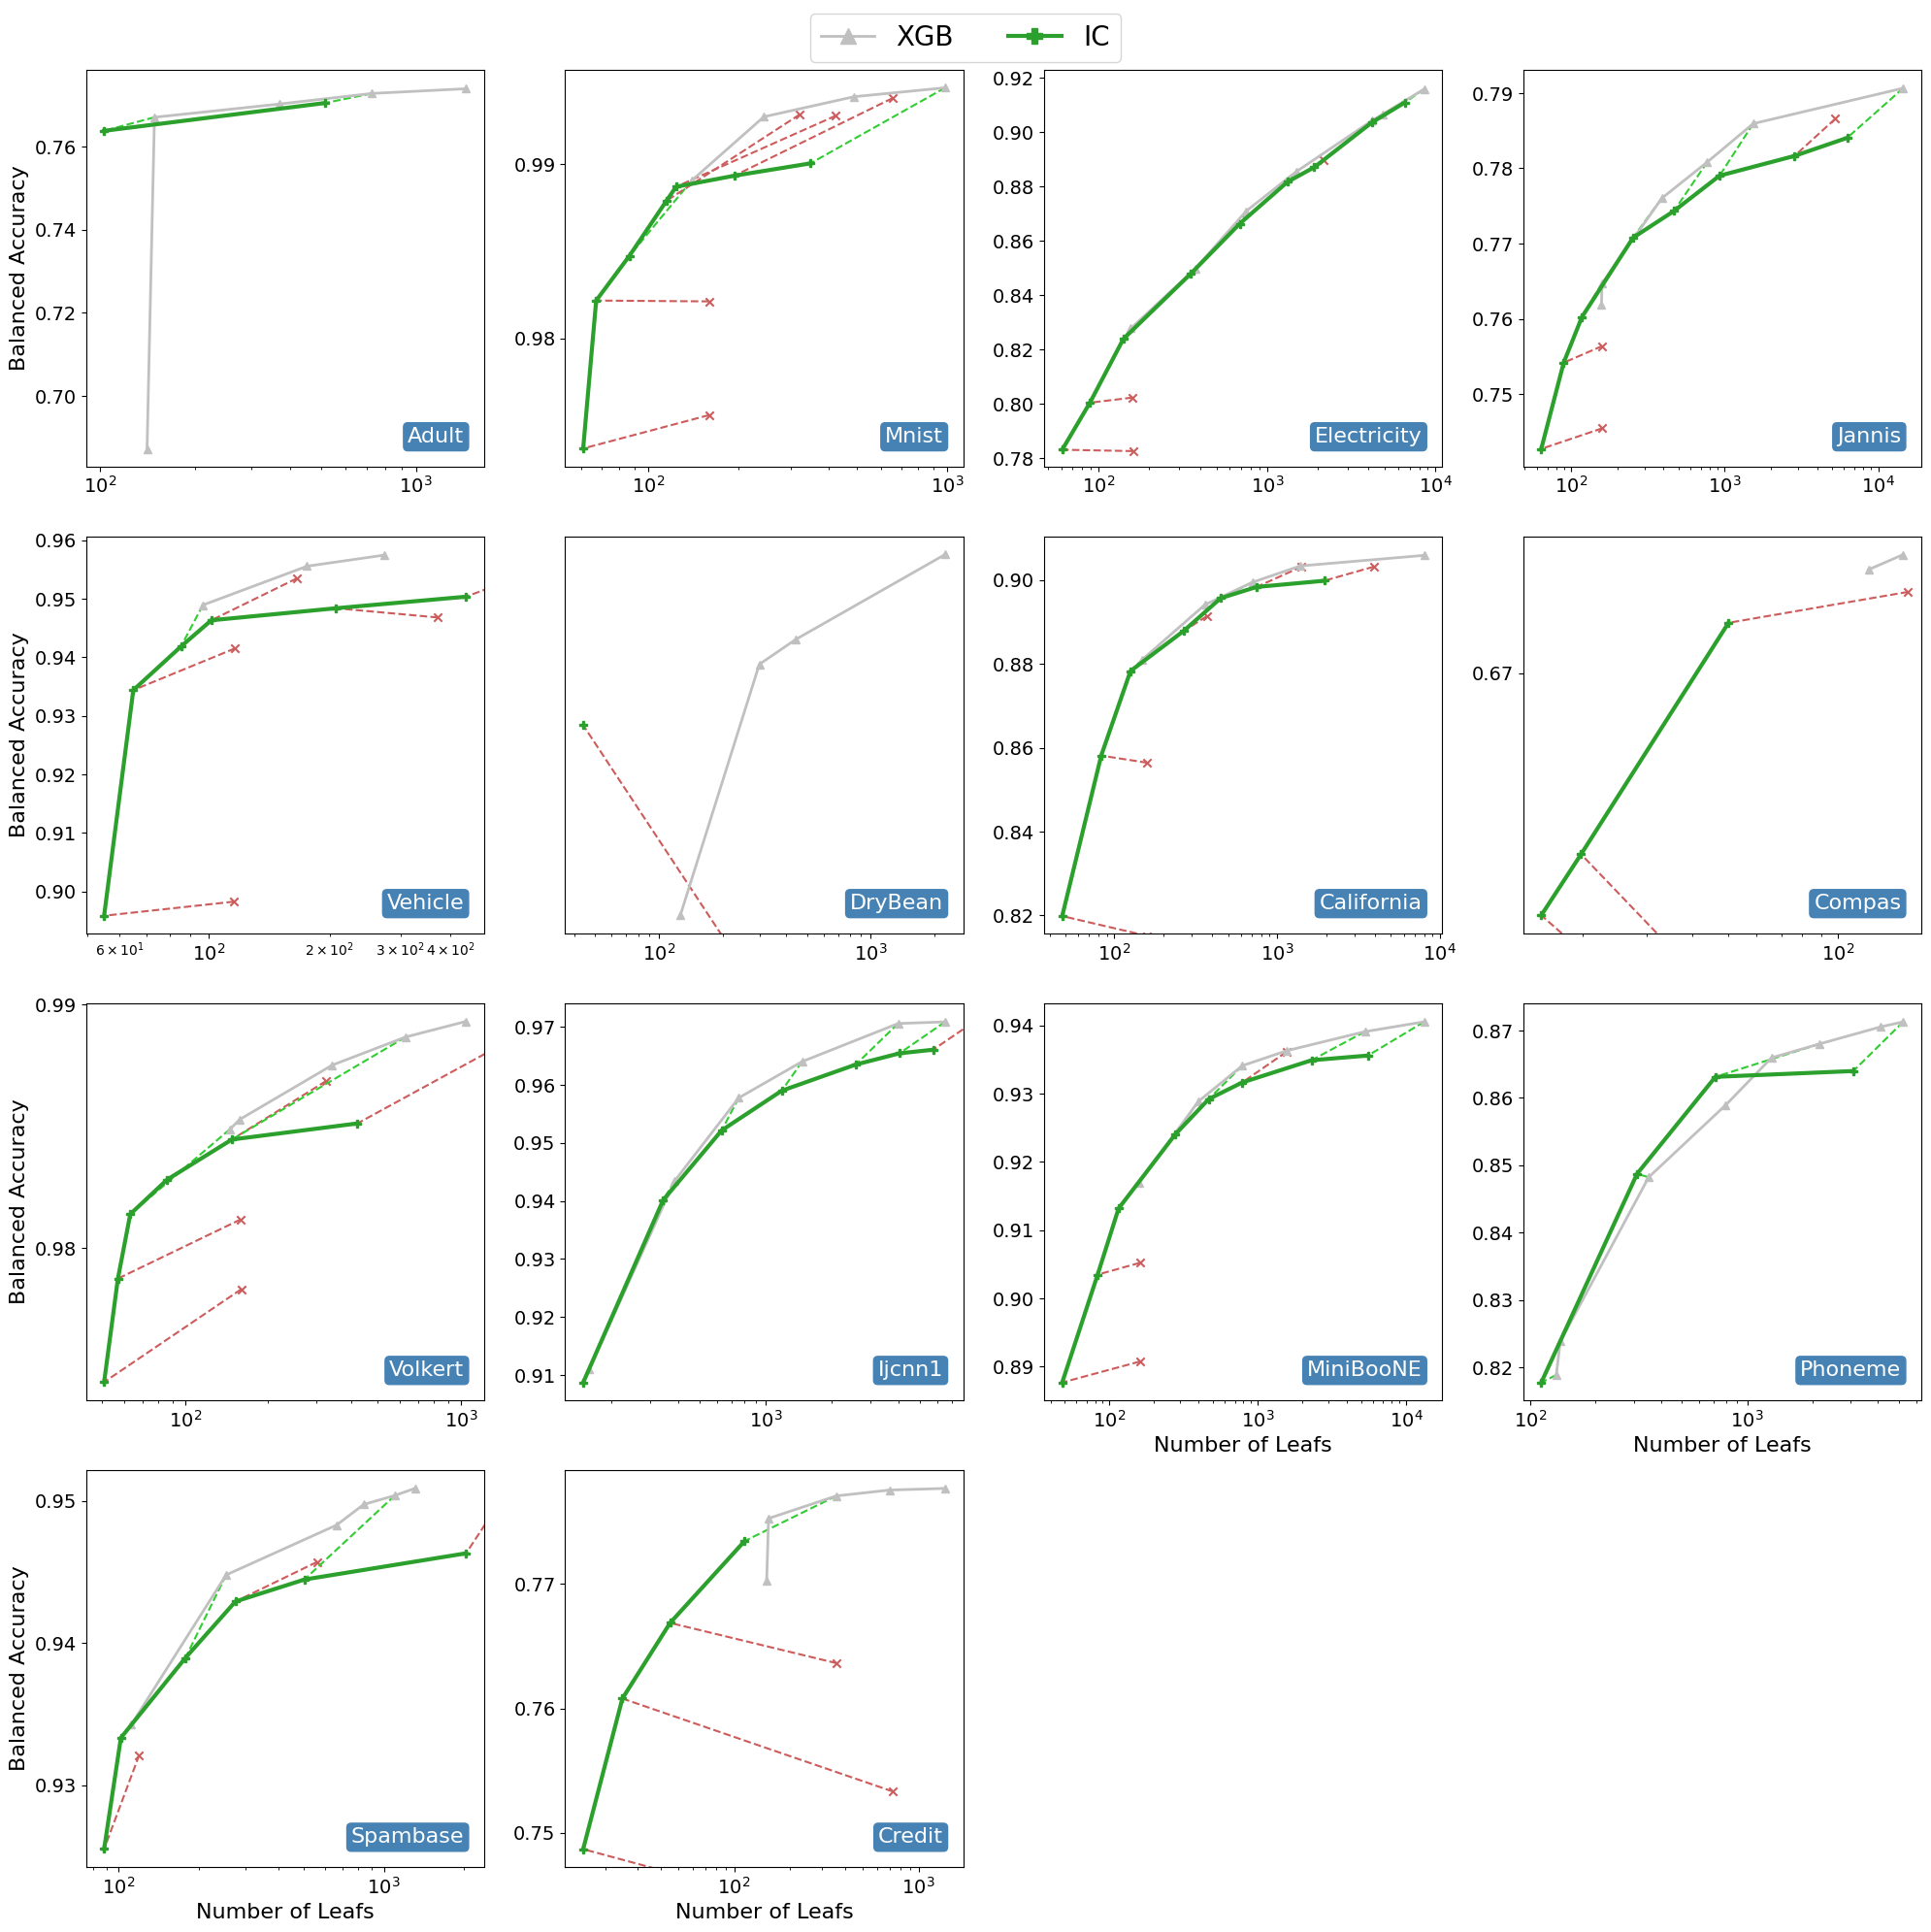

In [ ]:
import os
os.environ['PRADA_DATA_DIR'] = '/cw/dtaijupiter/NoCsBack/dtai/timo/prada_data'
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import util

# Change this parameter to select the method you want to compare to XGB
method = 'ic'
ds_names = {
    'Adult': 'Adult',
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}

indexes = {
    'gr': 0,
    'lrl1': 1,
    'ic': 2,
    'ours': 3,
    'forestprune': 4,
}

method_names = {
    'gr': 'GR',
    'ours': 'LOP',
    'ic': 'IC',
    'lrl1': 'LRL1',
    'xgb': 'XGB',
    'forestprune': 'FP'
}

marker_color_map = {
    'gr': ('C0', 'v'),
    'ours': ('black', 's'),
    'ic': ('C2', 'P'),
    'lrl1': ('C3', 'o'),
    'xgb': ('darkgray', '^'),
    'forestprune': ('C1', 'D')
}

fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()
datasets = ds_names.keys()
for d, ds in enumerate(datasets):
    settings = []
    for depth in [4, 6, 8]:
        for n_estimators in [10, 25, 50, 100]:
            for lr in [0.1, 0.25, 0.5, 1.0]:
                settings.append(f"{ds}_{n_estimators}_{depth}_{lr}")

    df = []
    refinement = None
    for setting in settings:
        n_leafs = 0
        n_leafs_after = 0
        mtest = 0
        mtest_after = 0
        for fold in range(5):
            n_leafs_after += results_horse_race[setting+f'_{fold}']['refinements'][indexes[method]]['nleafs']
            mtest_after += results_horse_race[setting+f'_{fold}']['refinements'][indexes[method]]['mtest']
            n_leafs += results_horse_race[setting+f'_{fold}']['nleafs']
            mtest += results_horse_race[setting+f'_{fold}']['mtest']
    
        df.append(np.array([n_leafs/5, mtest/5, n_leafs_after/5, mtest_after/5]))
    
    df = np.array(df)
    df = pd.DataFrame(df, columns=['nleafs', 'mtest', 'nleafs_after', 'mtest_after'])
    df['nleafs'] = df['nleafs'].astype(float)
    df['mtest'] = df['mtest'].astype(float)
    df['nleafs_after'] = df['nleafs_after'].astype(float)
    df['mtest_after'] = df['mtest_after'].astype(float)

    on_front_xgb, on_hull_xgb = util.pareto_front_xy(df['nleafs'].to_numpy(), df['mtest'].to_numpy())
    on_front_ours, on_hull_ours = util.pareto_front_xy(df['nleafs_after'].to_numpy(), df['mtest_after'].to_numpy())

    df['on_hull_xgb'] = on_hull_xgb
    df['on_hull_ours'] = on_hull_ours

    # axs[d].scatter(df[df['on_hull_ours'] == True]['nleafs_after'], df[df['on_hull_ours'] == True]['mtest_after'], color='black')
    # axs[d].scatter(df[df['on_hull_xgb'] == True]['nleafs'], df[df['on_hull_xgb'] == True]['mtest'], color='darkgray')
    

    xgb_hull = df[df['on_hull_xgb'] == True]
    ours_hull = df[df['on_hull_ours'] == True]

    xgb_hull_sorted = xgb_hull.sort_values(by='nleafs', ascending=True)
    ours_hull_sorted = ours_hull.sort_values(by='nleafs_after', ascending=True)

    for i in range(len(ours_hull)):
        row = ours_hull.iloc[i]
        if row['on_hull_xgb'] == True:
            axs[d].plot([row['nleafs'], row['nleafs_after']], [row['mtest'], row['mtest_after']], '--', color='limegreen')
        else:
            axs[d].plot([row['nleafs'], row['nleafs_after']], [row['mtest'], row['mtest_after']], '--', color='indianred')
            axs[d].scatter(row['nleafs'], row['mtest'], marker='x', color='indianred')

    axs[d].plot(xgb_hull_sorted['nleafs'], xgb_hull_sorted['mtest'], '-', color='silver', label='XGB', marker='^', linewidth=2)
    axs[d].plot(ours_hull_sorted['nleafs_after'], ours_hull_sorted['mtest_after'], '-', color=marker_color_map[method][0], label=method_names[method], marker=marker_color_map[method][1], linewidth=3)
    # axs[d].scatter(optimal_trees_df[optimal_trees_df['dname'] == ds]['nleafs'].mean(), optimal_trees_df[optimal_trees_df['dname'] == ds]['mtest'].mean(), marker='*', s=70, color='cornflowerblue', label='OSDT')
    if d % 4 == 0:
        axs[d].set_ylabel('Balanced Accuracy', fontsize=16)
    if d >= 10:
        axs[d].set_xlabel('Number of Leafs', fontsize=16)
    axs[d].set_xticks
    axs[d].set_xscale('log')
    axs[d].text(0.95, 0.05, ds_names[ds], transform=axs[d].transAxes, color='white', fontsize=16, verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))
    
    axs[d].tick_params(axis='both', labelsize=14)

    def filter_ticks_to_2_decimals(ticks):
        """Filter ticks to include only those with exactly 2 decimal places."""
        return [tick for tick in ticks if round(tick, 2) == round(tick, 4)]
    
    axs[d].set_yticks(filter_ticks_to_2_decimals(axs[d].get_yticks()))

    min_xlim = min(df[df['on_hull_ours'] == True]['nleafs_after'].min(), df[df['on_hull_xgb'] == True]['nleafs'].min())
    max_xlim = max(df[df['on_hull_xgb'] == True]['nleafs'].max(), df[df['on_hull_ours'] == True]['nleafs_after'].max())
    min_ylim = min(df[df['on_hull_ours'] == True]['mtest_after'].min(), df[df['on_hull_xgb'] == True]['mtest'].min())
    max_ylim = max(df[df['on_hull_xgb'] == True]['mtest'].max(), df[df['on_hull_ours'] == True]['mtest_after'].max())
    x_log_margin = np.exp(np.log(max_xlim / min_xlim) * 0.05)  # 10% margin in log space
    y_log_margin = np.exp(np.log(max_ylim / min_ylim) * 0.05)
    axs[d].set_xlim(min_xlim / x_log_margin, max_xlim * x_log_margin)
    axs[d].set_ylim(min_ylim / y_log_margin, max_ylim * y_log_margin)

# Hide the last two empty subplots
axs[-1].axis('off')
axs[-2].axis('off')

# Center the last row of subplots
fig.tight_layout(rect=[0, 0, 1, 0.97])

# Create a custom legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=20, markerscale=2)

plt.savefig('plots/pareto_fronts_all_{}.pdf'.format(method))


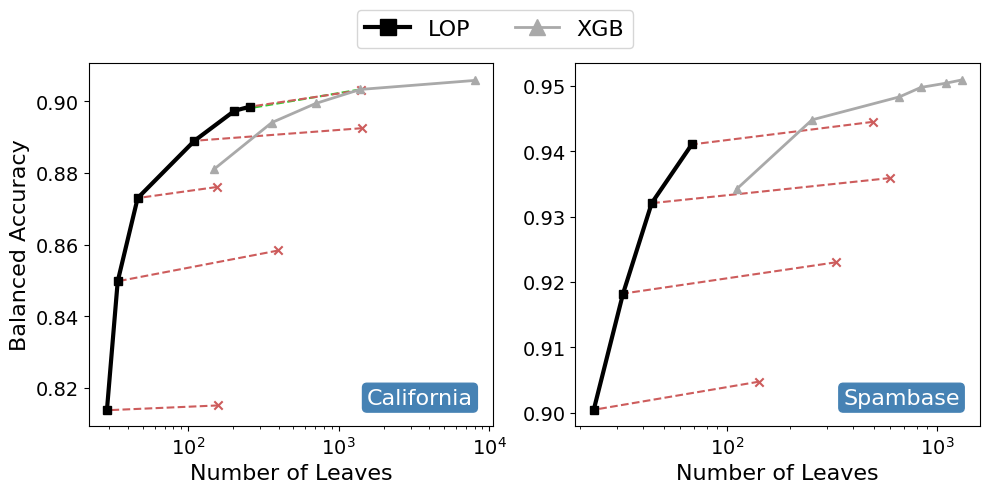

In [ ]:
from matplotlib import pyplot as plt
import os
os.environ['PRADA_DATA_DIR'] = '/cw/dtaijupiter/NoCsBack/dtai/timo/prada_data'
import util

method = 'ours'
ds_names = {
    'Adult': 'Adult',
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}

indexes = {
    'gr': 0,
    'lrl1': 1,
    'ic': 2,
    'ours': 3,
    'forestprune': 4,
}

method_names = {
    'gr': 'GR',
    'ours': 'LOP',
    'ic': 'IC',
    'lrl1': 'LRL1',
    'xgb': 'XGB',
    'forestprune': 'FP'
}

marker_color_map = {
    'gr': ('C0', 'v'),
    'ours': ('black', 's'),
    'ic': ('C2', 'P'),
    'lrl1': ('C3', 'o'),
    'xgb': ('darkgray', '^'),
    'forestprune': ('C1', 'D')
}

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()
datasets = ['California', 'Spambase']
for d, ds in enumerate(datasets):
    settings = []
    for depth in [4, 6, 8]:
        for n_estimators in [10, 25, 50, 100]:
            for lr in [0.1, 0.25, 0.5, 1.0]:
                settings.append(f"{ds}_{n_estimators}_{depth}_{lr}")

    df = []
    refinement = None
    for setting in settings:
        n_leafs = 0
        n_leafs_after = 0
        mtest = 0
        mtest_after = 0
        for fold in range(5):
            n_leafs_after += results_horse_race[setting+f'_{fold}']['refinements'][indexes[method]]['nleafs']
            mtest_after += results_horse_race[setting+f'_{fold}']['refinements'][indexes[method]]['mtest']
            n_leafs += results_horse_race[setting+f'_{fold}']['nleafs']
            mtest += results_horse_race[setting+f'_{fold}']['mtest']
    
        df.append(np.array([n_leafs/5, mtest/5, n_leafs_after/5, mtest_after/5]))
    
    df = np.array(df)
    df = pd.DataFrame(df, columns=['nleafs', 'mtest', 'nleafs_after', 'mtest_after'])
    df['nleafs'] = df['nleafs'].astype(float)
    df['mtest'] = df['mtest'].astype(float)
    df['nleafs_after'] = df['nleafs_after'].astype(float)
    df['mtest_after'] = df['mtest_after'].astype(float)

    on_front_xgb, on_hull_xgb = util.pareto_front_xy(df['nleafs'].to_numpy(), df['mtest'].to_numpy())
    on_front_ours, on_hull_ours = util.pareto_front_xy(df['nleafs_after'].to_numpy(), df['mtest_after'].to_numpy())

    df['on_hull_xgb'] = on_hull_xgb
    df['on_hull_ours'] = on_hull_ours

    # axs[d].scatter(df[df['on_hull_xgb'] == True]['nleafs'], df[df['on_hull_xgb'] == True]['mtest'], color='silver')
    # axs[d].scatter(df[df['on_hull_ours'] == True]['nleafs_after'], df[df['on_hull_ours'] == True]['mtest_after'], color='black')

    xgb_hull = df[df['on_hull_xgb'] == True]
    ours_hull = df[df['on_hull_ours'] == True]

    xgb_hull_sorted = xgb_hull.sort_values(by='nleafs', ascending=True)
    ours_hull_sorted = ours_hull.sort_values(by='nleafs_after', ascending=True)

    for i in range(len(ours_hull)):
        row = ours_hull.iloc[i]
        if row['on_hull_xgb'] == True:
            axs[d].plot([row['nleafs'], row['nleafs_after']], [row['mtest'], row['mtest_after']], '--', color='limegreen')
        else:
            axs[d].plot([row['nleafs'], row['nleafs_after']], [row['mtest'], row['mtest_after']], '--', color='indianred')
            axs[d].scatter(row['nleafs'], row['mtest'], marker='x', color='indianred')

    
    axs[d].plot(ours_hull_sorted['nleafs_after'], ours_hull_sorted['mtest_after'], '-', color=marker_color_map[method][0], label=method_names[method], marker=marker_color_map[method][1], linewidth=3)
    axs[d].plot(xgb_hull_sorted['nleafs'], xgb_hull_sorted['mtest'], '-', color='darkgray', label='XGB', marker='^', linewidth=2)
    # axs[d].scatter(optimal_trees_df[optimal_trees_df['dname'] == ds]['nleafs'].mean(), optimal_trees_df[optimal_trees_df['dname'] == ds]['mtest'].mean(), marker='*', s=70, color='cornflowerblue', label='OSDT')
    if d % 4 == 0:
        axs[d].set_ylabel('Balanced Accuracy', fontsize=16)
    axs[d].set_xlabel('Number of Leaves', fontsize=16)
    axs[d].set_xticks
    axs[d].set_xscale('log')
    axs[d].text(0.95, 0.05, ds_names[ds], transform=axs[d].transAxes, color='white', fontsize=16, verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))

    def filter_ticks_to_2_decimals(ticks):
        """Filter ticks to include only those with exactly 2 decimal places."""
        return [tick for tick in ticks if round(tick, 2) == round(tick, 4)]
    
    axs[d].set_yticks(filter_ticks_to_2_decimals(axs[d].get_yticks()))

    min_xlim = min(df[df['on_hull_ours'] == True]['nleafs_after'].min(), df[df['on_hull_xgb'] == True]['nleafs'].min())
    max_xlim = df[df['on_hull_xgb'] == True]['nleafs'].max()
    min_ylim = min(df[df['on_hull_ours'] == True]['mtest_after'].min(), df[df['on_hull_xgb'] == True]['mtest'].min())
    max_ylim = max(df[df['on_hull_xgb'] == True]['mtest'].max(), df[df['on_hull_ours'] == True]['mtest_after'].max())
    x_log_margin = np.exp(np.log(max_xlim / min_xlim) * 0.05)  # 10% margin in log space
    y_log_margin = np.exp(np.log(max_ylim / min_ylim) * 0.05)
    axs[d].set_xlim(min_xlim / x_log_margin, max_xlim * x_log_margin)
    axs[d].set_ylim(min_ylim / y_log_margin, max_ylim * y_log_margin)
    axs[d].tick_params(axis='both', labelsize=14)

    
# Hide the last two empty subplots

# Center the last row of subplots
fig.tight_layout(rect=[0, 0, 1, 0.9])

# Create a custom legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=16, markerscale=2)

plt.savefig('plots/pareto_fronts_subset.pdf')


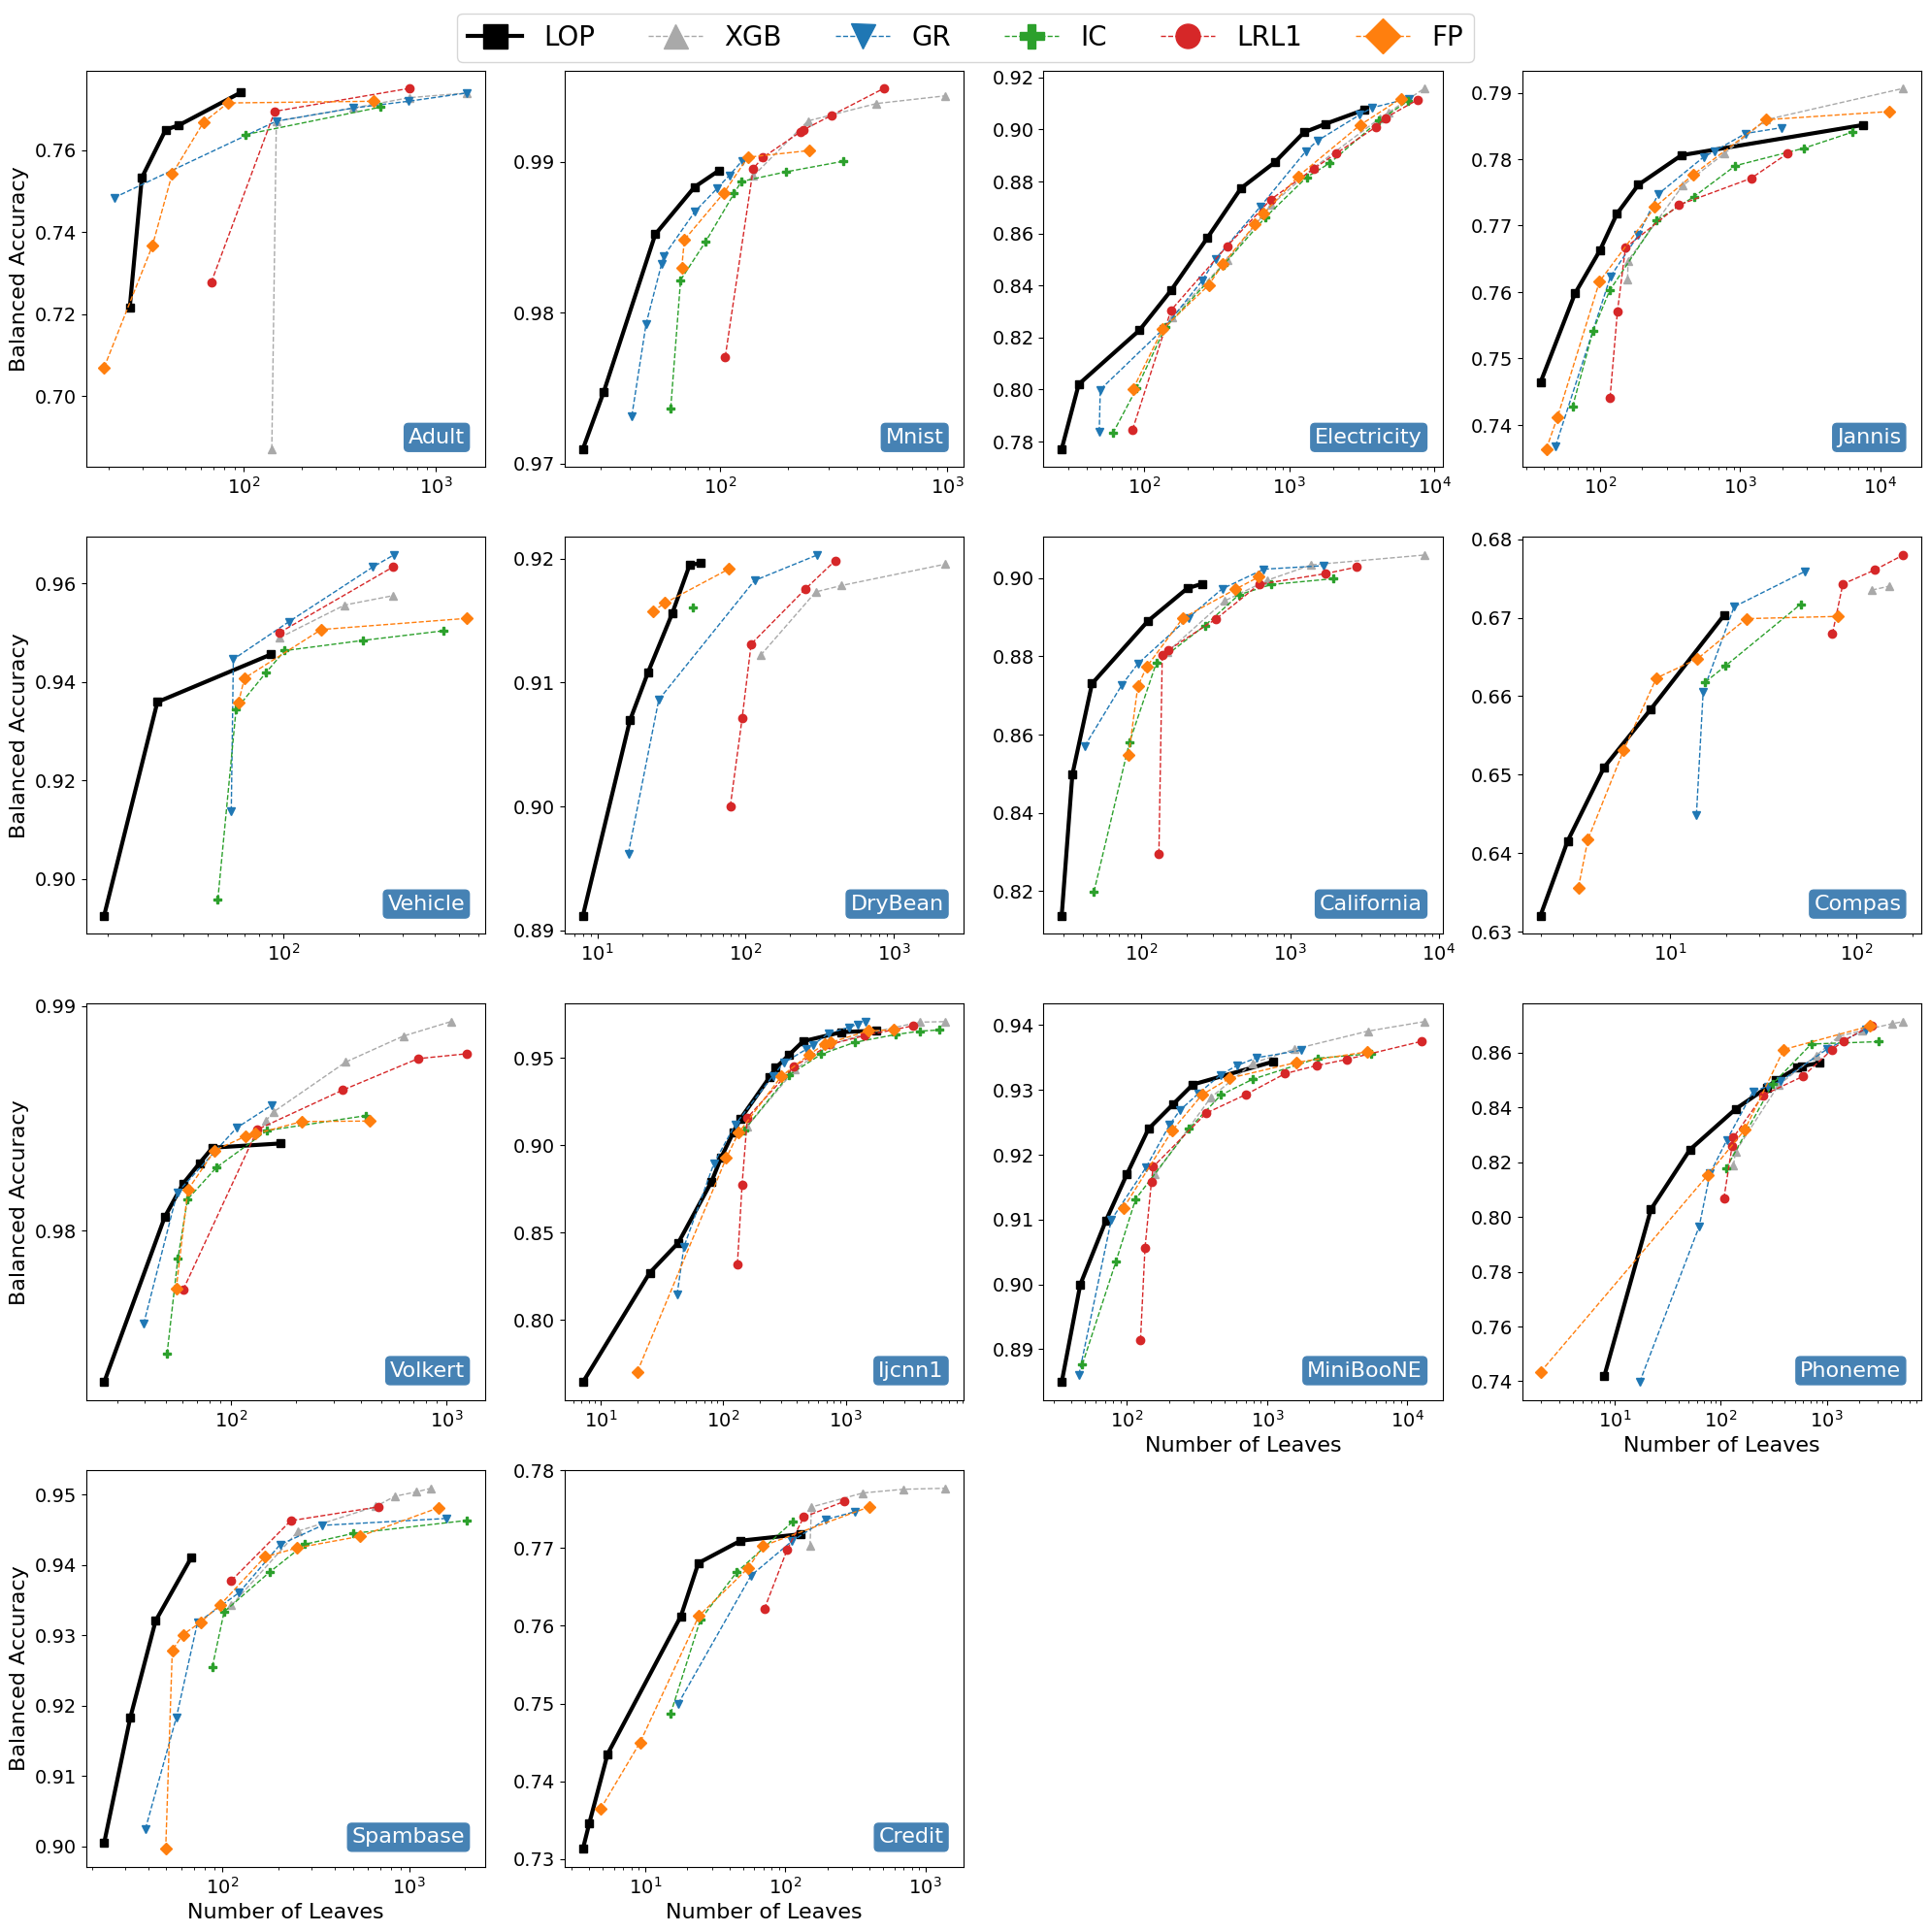

In [ ]:

from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator

import os
os.environ['PRADA_DATA_DIR'] = '/cw/dtaijupiter/NoCsBack/dtai/timo/prada_data'
import util

ds_names = {
    'Adult': 'Adult',
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}

method_names = {
    'gr': 'GR',
    'ours': 'LOP',
    'ic': 'IC',
    'lrl1': 'LRL1',
    'xgb': 'XGB',
    'forestprune': 'FP'
}

marker_color_map = {
    'gr': ('C0', 'v'),
    'ours': ('black', 's'),
    'ic': ('C2', 'P'),
    'lrl1': ('C3', 'o'),
    'xgb': ('darkgray', '^'),
    'forestprune': ('C1', 'D')
}
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()
datasets = ds_names.keys()
for d, ds in enumerate(datasets):
    avg_valid_bacc_keys = []
    for depth in [4, 6, 8]:
        for n_estimators in [10, 25, 50, 100]:
            for lr in [0.1, 0.25, 0.5, 1.0]:
                avg_valid_bacc = np.zeros(6)
                for fold in range(5):
                    for r, refinement in enumerate(results_horse_race[f"{ds}_{n_estimators}_{depth}_{lr}_{fold}"]['refinements']):
                        avg_valid_bacc[r] += refinement['mvalid']
                    avg_valid_bacc[5] += results_horse_race[f"{ds}_{n_estimators}_{depth}_{lr}_{fold}"]['mvalid']
                avg_valid_bacc /= 5
                avg_valid_bacc_keys.append((f"{ds}_{n_estimators}_{depth}_{lr}", avg_valid_bacc))

    nb_best = 48
    best_settings_gr = sorted(avg_valid_bacc_keys, key=lambda x: x[1][0], reverse=True)[:nb_best]
    best_settings_ours = sorted(avg_valid_bacc_keys, key=lambda x: x[1][1], reverse=True)[:nb_best]
    best_settings_ic = sorted(avg_valid_bacc_keys, key=lambda x: x[1][2], reverse=True)[:nb_best]
    best_settings_lrl1 = sorted(avg_valid_bacc_keys, key=lambda x: x[1][3], reverse=True)[:nb_best]
    best_settings_xgb = sorted(avg_valid_bacc_keys, key=lambda x: x[1][5], reverse=True)[:nb_best]
    best_settings_fp = sorted(best_settings_gr, key=lambda x: x[1][4], reverse=True)[:nb_best]

    df = []
    for r, settings in enumerate([best_settings_gr, best_settings_ours, best_settings_ic, best_settings_lrl1, best_settings_fp]):
        refinement = None
        for setting, _ in settings:
            n_leafs = 0
            mtest = 0
            for fold in range(5):
                n_leafs += results_horse_race[setting+f'_{fold}']['refinements'][r]['nleafs']
                mtest += results_horse_race[setting+f'_{fold}']['refinements'][r]['mtest']
            if refinement == None:
                refinement = results_horse_race[setting+f'_{fold}']['refinements'][r]['penalty']
            df.append(np.array([refinement, n_leafs/5, mtest/5]))

    for setting, _ in best_settings_xgb:
        n_leafs = 0
        mtest = 0
        for fold in range(5):
            n_leafs += results_horse_race[setting+f'_{fold}']['nleafs']
            mtest += results_horse_race[setting+f'_{fold}']['mtest']
        df.append(np.array(['xgb', n_leafs/5, mtest/5]))
    
    df = np.array(df)

    df = pd.DataFrame(df, columns=['penalty', 'nleafs', 'mtest'])
    df['nleafs'] = df['nleafs'].astype(float)
    df['mtest'] = df['mtest'].astype(float)

    for r, ref in enumerate(['ours', 'xgb', 'gr', 'ic', 'lrl1', 'forestprune']):
        on_front, on_hull = util.pareto_front_xy(df[df['penalty'] == ref]['nleafs'].to_numpy(), df[df['penalty'] == ref]['mtest'].to_numpy())
        # axs[d].scatter(df[(df['penalty'] == ref)][on_hull == True]['nleafs'], df[df['penalty'] == ref][on_hull == True]['mtest'], label=method_names[ref])
        # axs[d].scatter(df[(df['penalty'] == ref)]['nleafs'], df[df['penalty'] == ref]['mtest'], alpha=0.2, color='C' + str(r))
        df_sorted = df[df['penalty'] == ref][on_hull == True].sort_values(by='nleafs', ascending=True)
        if ref == 'ours':
            axs[d].plot(df_sorted['nleafs'], df_sorted['mtest'], '-', color=marker_color_map[ref][0], marker=marker_color_map[ref][1], linewidth=3, label=method_names[ref])
        else:
            axs[d].plot(df_sorted['nleafs'], df_sorted['mtest'], '--', color=marker_color_map[ref][0], marker=marker_color_map[ref][1], linewidth=1, label=method_names[ref])
    # axs[d].scatter(optimal_trees_df[optimal_trees_df['dname'] == ds]['nleafs'].mean(), optimal_trees_df[optimal_trees_df['dname'] == ds]['mtest'].mean(), marker='*', s=70, color='cornflowerblue', label='OSDT')

    if d % 4 == 0:
        axs[d].set_ylabel('Balanced Accuracy', fontsize=16)
    if d >= 10:
        axs[d].set_xlabel('Number of Leaves', fontsize=16)
    axs[d].set_xticks
    axs[d].set_xscale('log')
    axs[d].text(0.95, 0.05, ds_names[ds], transform=axs[d].transAxes, color='white', fontsize=16, verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))
    
    axs[d].tick_params(axis='both', labelsize=14)

    def filter_ticks_to_2_decimals(ticks):
        """Filter ticks to include only those with exactly 2 decimal places."""
        return [tick for tick in ticks if round(tick, 2) == round(tick, 4)]
    
    axs[d].set_yticks(filter_ticks_to_2_decimals(axs[d].get_yticks()))

    axs[d].margins(x=0.05, y=0.05)


# Hide the last two empty subplots
axs[-1].axis('off')
axs[-2].axis('off')

# Center the last row of subplots
fig.tight_layout(rect=[0, 0, 1, 0.97])

# Create a custom legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=20, markerscale=3)

plt.savefig('plots/pareto_fronts_all_total.pdf')


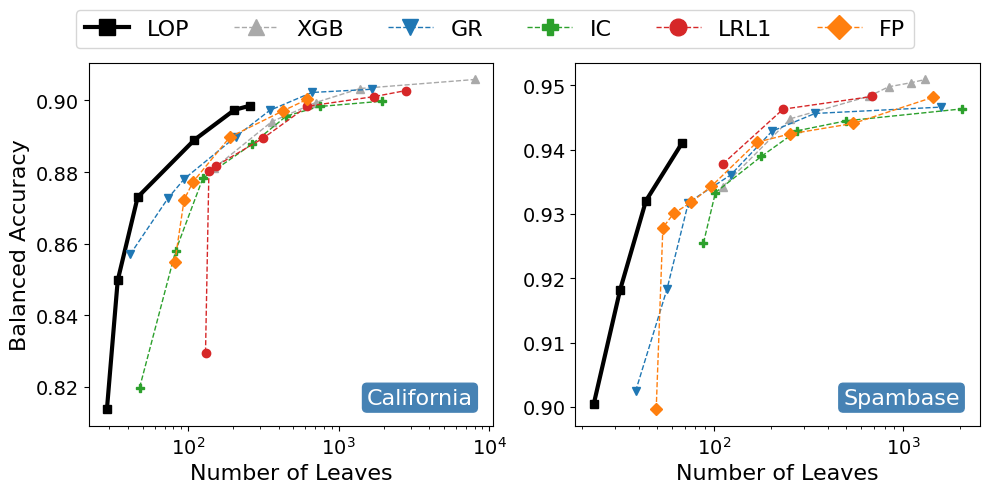

In [ ]:

from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator

import os
os.environ['PRADA_DATA_DIR'] = '/cw/dtaijupiter/NoCsBack/dtai/timo/prada_data'
import util

ds_names = {
    'Adult': 'Adult',
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}

method_names = {
    'gr': 'GR',
    'ours': 'LOP',
    'ic': 'IC',
    'lrl1': 'LRL1',
    'xgb': 'XGB',
    'forestprune': 'FP'
}

marker_color_map = {
    'gr': ('C0', 'v'),
    'ours': ('black', 's'),
    'ic': ('C2', 'P'),
    'lrl1': ('C3', 'o'),
    'xgb': ('darkgray', '^'),
    'forestprune': ('C1', 'D')
}
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()
datasets = ['California', 'Spambase']
for d, ds in enumerate(datasets):
    avg_valid_bacc_keys = []
    for depth in [4, 6, 8]:
        for n_estimators in [10, 25, 50, 100]:
            for lr in [0.1, 0.25, 0.5, 1.0]:
                avg_valid_bacc = np.zeros(6)
                for fold in range(5):
                    for r, refinement in enumerate(results_horse_race[f"{ds}_{n_estimators}_{depth}_{lr}_{fold}"]['refinements']):
                        avg_valid_bacc[r] += refinement['mvalid']
                    avg_valid_bacc[5] += results_horse_race[f"{ds}_{n_estimators}_{depth}_{lr}_{fold}"]['mvalid']
                avg_valid_bacc /= 5
                avg_valid_bacc_keys.append((f"{ds}_{n_estimators}_{depth}_{lr}", avg_valid_bacc))

    nb_best = 48
    best_settings_gr = sorted(avg_valid_bacc_keys, key=lambda x: x[1][0], reverse=True)[:nb_best]
    best_settings_ours = sorted(avg_valid_bacc_keys, key=lambda x: x[1][1], reverse=True)[:nb_best]
    best_settings_ic = sorted(avg_valid_bacc_keys, key=lambda x: x[1][2], reverse=True)[:nb_best]
    best_settings_lrl1 = sorted(avg_valid_bacc_keys, key=lambda x: x[1][3], reverse=True)[:nb_best]
    best_settings_xgb = sorted(avg_valid_bacc_keys, key=lambda x: x[1][5], reverse=True)[:nb_best]
    best_settings_fp = sorted(best_settings_gr, key=lambda x: x[1][4], reverse=True)[:nb_best]


    df = []
    for r, settings in enumerate([best_settings_gr, best_settings_ours, best_settings_ic, best_settings_lrl1, best_settings_fp]):
        refinement = None
        for setting, _ in settings:
            n_leafs = 0
            mtest = 0
            for fold in range(5):
                n_leafs += results_horse_race[setting+f'_{fold}']['refinements'][r]['nleafs']
                mtest += results_horse_race[setting+f'_{fold}']['refinements'][r]['mtest']
            if refinement == None:
                refinement = results_horse_race[setting+f'_{fold}']['refinements'][r]['penalty']
            df.append(np.array([refinement, n_leafs/5, mtest/5]))

    for setting, _ in best_settings_xgb:
        n_leafs = 0
        mtest = 0
        for fold in range(5):
            n_leafs += results_horse_race[setting+f'_{fold}']['nleafs']
            mtest += results_horse_race[setting+f'_{fold}']['mtest']
        df.append(np.array(['xgb', n_leafs/5, mtest/5]))
    
    df = np.array(df)

    df = pd.DataFrame(df, columns=['penalty', 'nleafs', 'mtest'])
    df['nleafs'] = df['nleafs'].astype(float)
    df['mtest'] = df['mtest'].astype(float)

    for r, ref in enumerate(['ours', 'xgb', 'gr', 'ic', 'lrl1', 'forestprune']):
        on_front, on_hull = util.pareto_front_xy(df[df['penalty'] == ref]['nleafs'].to_numpy(), df[df['penalty'] == ref]['mtest'].to_numpy())
        # axs[d].scatter(df[(df['penalty'] == ref)][on_hull == True]['nleafs'], df[df['penalty'] == ref][on_hull == True]['mtest'], label=method_names[ref])
        # axs[d].scatter(df[(df['penalty'] == ref)]['nleafs'], df[df['penalty'] == ref]['mtest'], alpha=0.2, color='C' + str(r))
        df_sorted = df[df['penalty'] == ref][on_hull == True].sort_values(by='nleafs', ascending=True)
        if ref == 'ours':
            axs[d].plot(df_sorted['nleafs'], df_sorted['mtest'], '-', color=marker_color_map[ref][0], marker=marker_color_map[ref][1], linewidth=3, label=method_names[ref])
        else:
            axs[d].plot(df_sorted['nleafs'], df_sorted['mtest'], '--', color=marker_color_map[ref][0], marker=marker_color_map[ref][1], linewidth=1, label=method_names[ref])
    # axs[d].scatter(optimal_trees_df[optimal_trees_df['dname'] == ds]['nleafs'].mean(), optimal_trees_df[optimal_trees_df['dname'] == ds]['mtest'].mean(), marker='*', s=70, color='cornflowerblue', label='OSDT')

    if d % 4 == 0:
        axs[d].set_ylabel('Balanced Accuracy', fontsize=16)
    axs[d].set_xlabel('Number of Leaves', fontsize=16)
    axs[d].set_xticks
    axs[d].set_xscale('log')
    axs[d].text(0.95, 0.05, ds_names[ds], transform=axs[d].transAxes, color='white', fontsize=16, verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))
    
    axs[d].tick_params(axis='both', labelsize=14)

    def filter_ticks_to_2_decimals(ticks):
        """Filter ticks to include only those with exactly 2 decimal places."""
        return [tick for tick in ticks if round(tick, 2) == round(tick, 4)]
    
    axs[d].set_yticks(filter_ticks_to_2_decimals(axs[d].get_yticks()))

    axs[d].margins(x=0.05, y=0.05)


# Center the last row of subplots
fig.tight_layout(rect=[0, 0, 1, 0.9])

# Create a custom legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=16, markerscale=2)

plt.savefig('plots/pareto_fronts_subset_total.pdf')


## Scaling plots

In [88]:
import ast
import numpy as np
import pandas as pd
xgb_scaling_trees_file = 'results/xgb_classification_scaling_trees.txt'
xgb_scaling_trees_results = {}
datasets = ['California', 'Adult', 'Phoneme', 'Spambase']

with open(xgb_scaling_trees_file, 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line_dict = ast.literal_eval(str(line))
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        xgb_scaling_trees_results[key] = line_dict

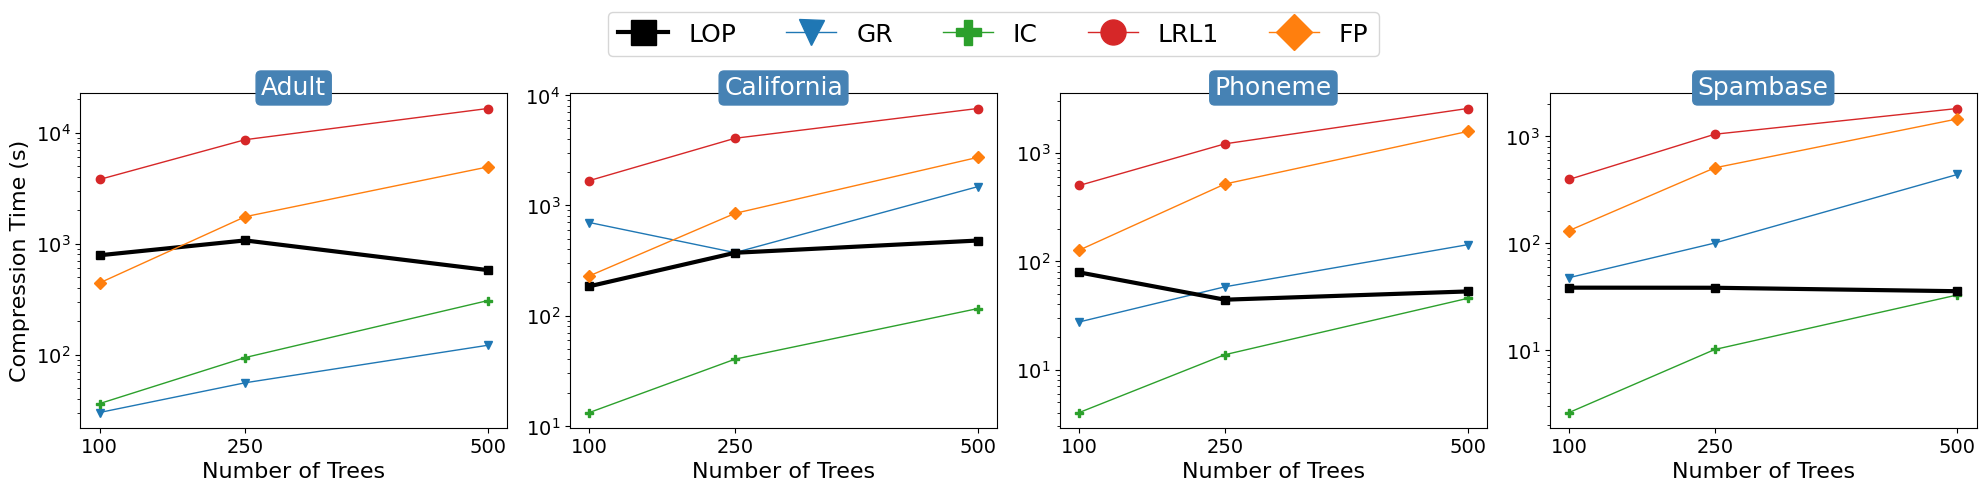

In [ ]:
method_names = {
    'gr': 'GR',
    'ours': 'LOP',
    'ic': 'IC',
    'lrl1': 'LRL1',
    'xgb': 'XGB',
    'forestprune': 'FP'
}

marker_color_map = {
    'gr': ('C0', 'v'),
    'ours': ('black', 's'),
    'ic': ('C2', 'P'),
    'lrl1': ('C3', 'o'),
    'xgb': ('darkgray', '^'),
    'forestprune': ('C1', 'D')
}

ds_names = {
    'Adult': 'Adult',
    'Mnist[2v4]': 'Mnist',
    'Electricity': 'Electricity',
    'Jannis': 'Jannis',
    'Vehicle': 'Vehicle',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'CompasTwoYears': 'Compas',
    'Volkert[2v7]': 'Volkert',
    'Ijcnn1': 'Ijcnn1',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Credit': 'Credit',
}
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs = axs.flatten()
datasets = sorted(datasets)  # Sort datasets alphabetically
depth = 6
lr = 0.1
nb_trees = [100, 250, 500]
for d, ds in enumerate(datasets):
    for i, method in enumerate(['gr', 'ic', 'lrl1', 'ours', 'forestprune']):
        runtimes = []
        for nb_tree in nb_trees:
            runtime = 0
            for fold in range(5):
                key = f"{ds}_{nb_tree}_{depth}_{lr}_{fold}"
                if key in xgb_scaling_trees_results:
                    runtime += xgb_scaling_trees_results[key]['refinements'][i]['compr_time']
            runtimes.append(runtime / 5)  # Average runtime over folds
        if method == 'ours':
            axs[d].plot(nb_trees, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=3)
        else:
            axs[d].plot(nb_trees, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=1)    
    axs[d].set_xlabel('Number of Trees', fontsize=16)
    if d == 0:  # Only add y-axis label for the leftmost subplot
        axs[d].set_ylabel('Compression Time (s)', fontsize=16)
    axs[d].set_xticks(nb_trees)
    axs[d].set_yscale('log')
    axs[d].tick_params(axis='both', labelsize=14)

# Add dataset name in a blue box above every subplot
for ax, ds in zip(axs, datasets):
    ax.text(0.5, 0.98, ds_names[ds], transform=ax.transAxes, color='white', fontsize=18, 
            verticalalignment='bottom', horizontalalignment='center', 
            bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))

fig.tight_layout(rect=[0, 0, 1, 0.87])

handles, labels = axs[0].get_legend_handles_labels()
lop_index = labels.index('LOP')
handles.insert(0, handles.pop(lop_index))
labels.insert(0, labels.pop(lop_index))
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=18, markerscale=3)
plt.savefig('plots/xgb_scaling_trees.pdf')


In [97]:
import ast
import numpy as np
import pandas as pd
xgb_scaling_depth_file = 'results/xgb_classification_scaling_depth.txt'
xgb_scaling_depth_results = {}
datasets = ['California', 'Adult', 'Phoneme', 'Spambase']

with open(xgb_scaling_depth_file, 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line_dict = ast.literal_eval(str(line))
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        xgb_scaling_depth_results[key] = line_dict

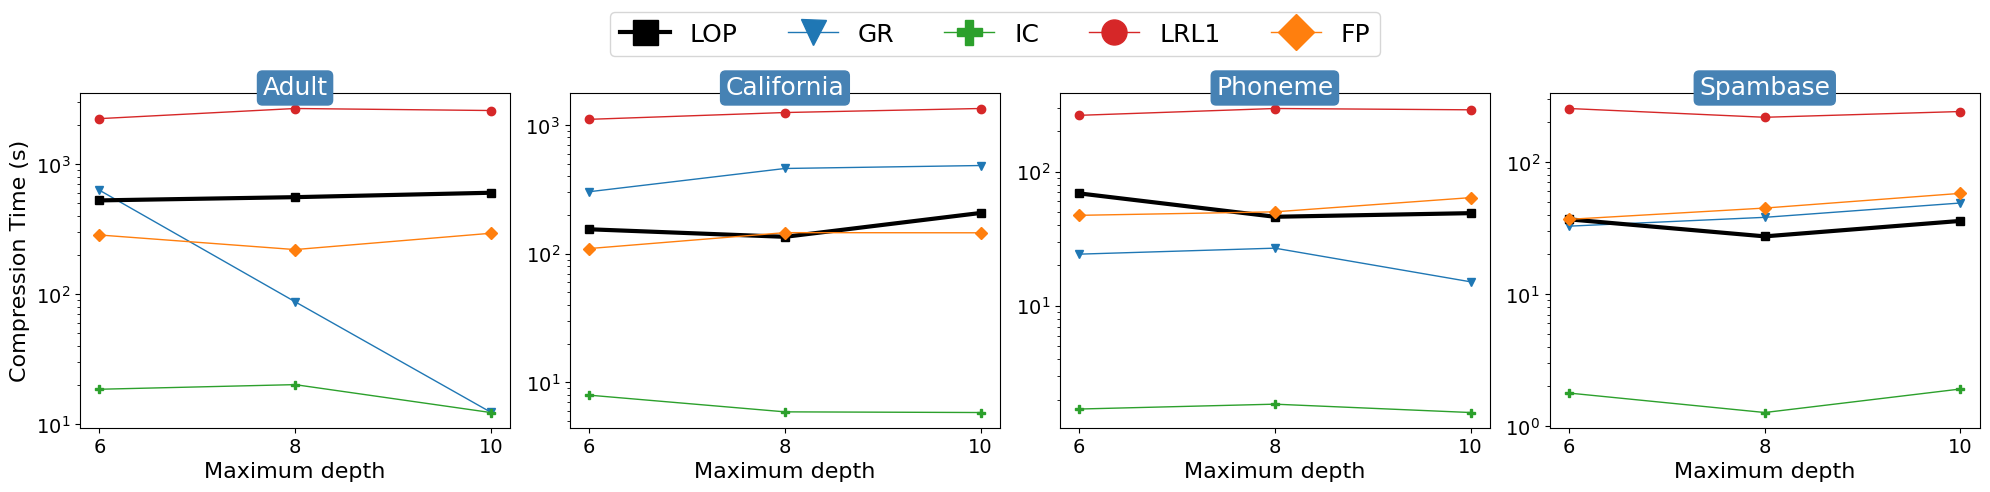

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs = axs.flatten()
datasets = sorted(datasets)  # Sort datasets alphabetically
depth = [6, 8, 10]
lr = 0.1
nb_trees = 50

for d, ds in enumerate(datasets):
    for i, method in enumerate(['gr', 'ic', 'lrl1', 'ours', 'forestprune']):
        runtimes = []
        for dept in depth:
            runtime = 0
            for fold in range(5):
                key = f"{ds}_{nb_trees}_{dept}_{lr}_{fold}"
                if key in xgb_scaling_depth_results:
                    runtime += xgb_scaling_depth_results[key]['refinements'][i]['compr_time']
            runtimes.append(runtime / 5)  # Average runtime over folds
        if method == 'ours':
            axs[d].plot(depth, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=3)
        else:
            axs[d].plot(depth, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=1)
    axs[d].set_xlabel('Maximum depth', fontsize=16)
    if d == 0:  # Only add y-axis label for the leftmost subplot
        axs[d].set_ylabel('Compression Time (s)', fontsize=16)
    axs[d].set_xticks(depth)
    axs[d].set_yscale('log')
    axs[d].tick_params(axis='both', labelsize=14)

# Add dataset name in a blue box above every subplot
for ax, ds in zip(axs, datasets):
    ax.text(0.5, 0.98, ds_names[ds], transform=ax.transAxes, color='white', fontsize=18, 
            verticalalignment='bottom', horizontalalignment='center', 
            bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))

fig.tight_layout(rect=[0, 0, 1, 0.87])

# Create a custom legend with LOP first
handles, labels = axs[0].get_legend_handles_labels()
lop_index = labels.index('LOP')
handles.insert(0, handles.pop(lop_index))
labels.insert(0, labels.pop(lop_index))
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=18, markerscale=3)
plt.savefig('plots/xgb_scaling_depth.pdf')


In [101]:
import ast
import numpy as np
import pandas as pd
rf_scaling_trees_file = 'results/rf_classification_scaling_trees.txt'
rf_scaling_trees_results = {}
datasets = ['California', 'Adult', 'Phoneme', 'Spambase']

with open(rf_scaling_trees_file, 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['fold']}"
        rf_scaling_trees_results[key] = line_dict

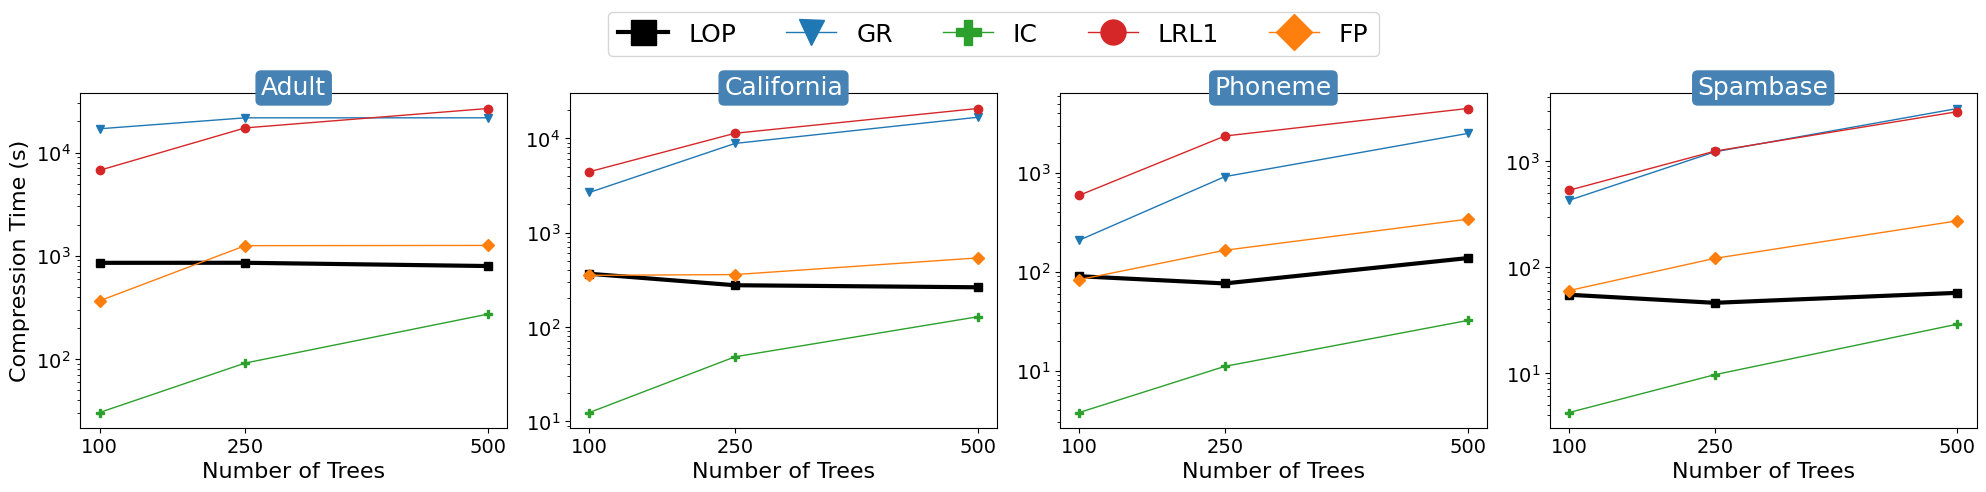

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs = axs.flatten()

datasets = sorted(datasets)  # Sort datasets alphabetically
depth = 10
nb_trees = [100, 250, 500]

for d, ds in enumerate(datasets):
    for i, method in enumerate(['gr', 'ic', 'lrl1', 'ours', 'forestprune']):
        runtimes = []
        for nb_tree in nb_trees:
            runtime = 0
            for fold in range(5):
                key = f"{ds}_{nb_tree}_{depth}_{fold}"
                if key in rf_scaling_trees_results:
                    runtime += rf_scaling_trees_results[key]['refinements'][i]['compr_time']
            runtimes.append(runtime / 5)  # Average runtime over folds
        if method == 'ours':
            axs[d].plot(nb_trees, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=3)
        else:
            axs[d].plot(nb_trees, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=1)    
    axs[d].set_xlabel('Number of Trees', fontsize=16)
    if d == 0:  # Only add y-axis label for the leftmost subplot
        axs[d].set_ylabel('Compression Time (s)', fontsize=16)
    axs[d].set_xticks(nb_trees)
    axs[d].set_yscale('log')
    axs[d].tick_params(axis='both', labelsize=14)

# Add dataset name in a blue box above every subplot
for ax, ds in zip(axs, datasets):
    ax.text(0.5, 0.98, ds_names[ds], transform=ax.transAxes, color='white', fontsize=18, 
            verticalalignment='bottom', horizontalalignment='center', 
            bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))

fig.tight_layout(rect=[0, 0, 1, 0.87])

handles, labels = axs[0].get_legend_handles_labels()
lop_index = labels.index('LOP')
handles.insert(0, handles.pop(lop_index))
labels.insert(0, labels.pop(lop_index))
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=18, markerscale=3)
plt.savefig('plots/rf_scaling_trees.pdf')


In [103]:
import ast
import numpy as np
import pandas as pd
rf_scaling_depth_file = 'results/rf_classification_scaling_depth.txt'
rf_scaling_depth_results = {}
datasets = ['California', 'Adult', 'Phoneme', 'Spambase']

with open(rf_scaling_depth_file, 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['fold']}"
        rf_scaling_depth_results[key] = line_dict

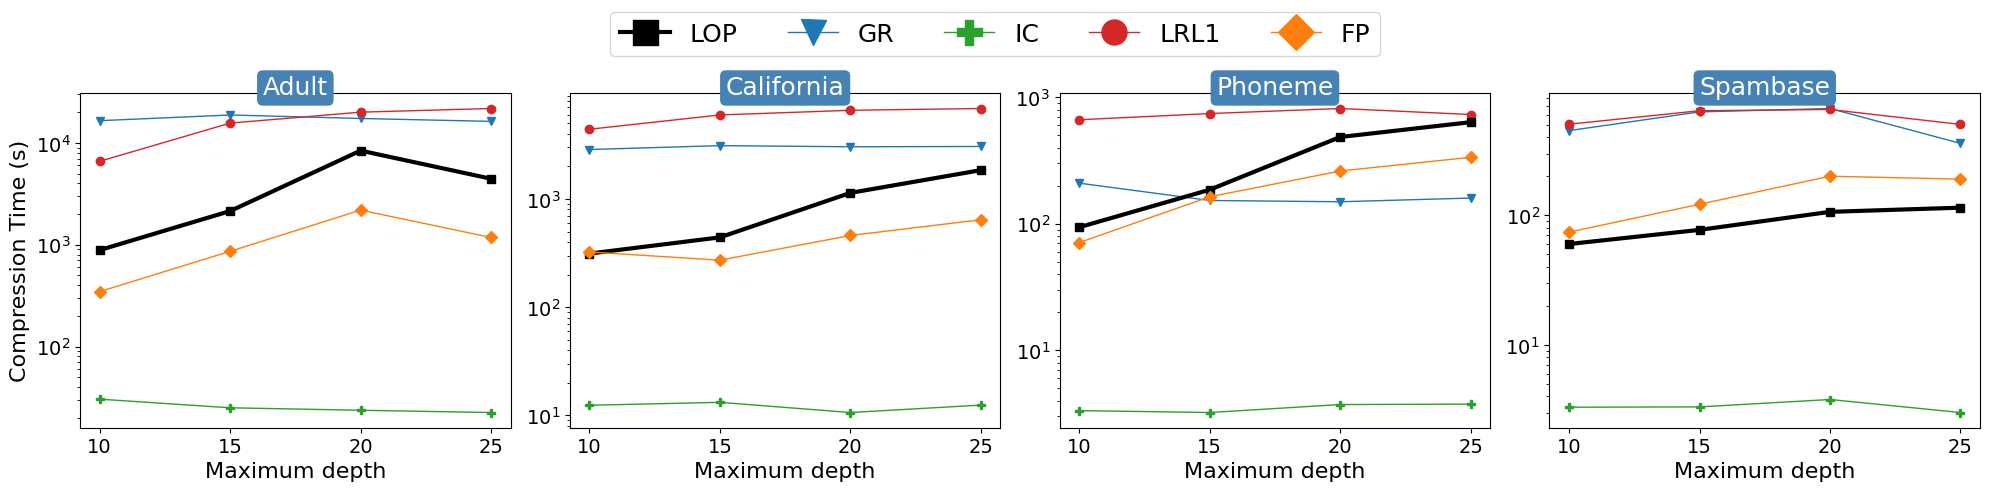

In [ ]:
datasets = sorted(datasets)  # Sort datasets alphabetically
fig, axs = plt.subplots(1, 4, figsize=(20, 5))  # Adjust to 4 subplots for consistency
axs = axs.flatten()
depth = [10, 15, 20, 25]
nb_trees = 100

for d, ds in enumerate(datasets[:4]):  # Limit to 4 datasets for consistency
    for i, method in enumerate(['gr', 'ic', 'lrl1', 'ours', 'forestprune']):
        runtimes = []
        for dept in depth:
            runtime = 0
            for fold in range(5):
                key = f"{ds}_{nb_trees}_{dept}_{fold}"
                if key in rf_scaling_depth_results:
                    runtime += rf_scaling_depth_results[key]['refinements'][i]['compr_time']
            runtimes.append(runtime / 5)  # Average runtime over folds
        if method == 'ours':
            axs[d].plot(depth, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=3)
        else:
            axs[d].plot(depth, runtimes, label=method_names[method], marker=marker_color_map[method][1], color=marker_color_map[method][0], linewidth=1)
    axs[d].set_xlabel('Maximum depth', fontsize=16)
    if d == 0:  # Only add y-axis label for the leftmost subplot
        axs[d].set_ylabel('Compression Time (s)', fontsize=16)
    axs[d].set_xticks(depth)
    axs[d].set_yscale('log')
    axs[d].tick_params(axis='both', labelsize=14)

# Add dataset name in a blue box above every subplot
for ax, ds in zip(axs, datasets[:4]):
    ax.text(0.5, 0.98, ds_names[ds], transform=ax.transAxes, color='white', fontsize=18, 
            verticalalignment='bottom', horizontalalignment='center', 
            bbox=dict(facecolor='steelblue', edgecolor='steelblue', boxstyle='round,pad=0.2'))

fig.tight_layout(rect=[0, 0, 1, 0.87])

# Create a custom legend with LOP first
handles, labels = axs[0].get_legend_handles_labels()
lop_index = labels.index('LOP')
handles.insert(0, handles.pop(lop_index))
labels.insert(0, labels.pop(lop_index))
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=18, markerscale=3)
plt.savefig('plots/rf_scaling_depth.pdf')


In [106]:
# Print timeouts for scaling experiments
import pandas as pd
from collections import defaultdict

# Define the scaling experiment results
scaling_results = {
    "xgb_scaling_trees": xgb_scaling_trees_results,
    "xgb_scaling_depth": xgb_scaling_depth_results,
    "rf_scaling_trees": rf_scaling_trees_results,
    "rf_scaling_depth": rf_scaling_depth_results,
}

# Initialize a dictionary to store timeout records for each experiment
timeout_records = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Process each scaling experiment
for experiment_name, results in scaling_results.items():
    for k, result in results.items():
        dname = result['dname']
        n_estimators = result.get('ntrees', None)
        max_depth = result.get('max_depth', None)
        setting = (n_estimators, max_depth)
        
        for refinement in result['refinements']:
            penalty = refinement['penalty']
            if refinement['compr_time'] > 21600:
                timeout_records[experiment_name][dname][setting].append(penalty)

# Build tables for each experiment
experiment_dfs = {}
for experiment_name, records in timeout_records.items():
    rows = []
    for dname in sorted(records):
        for setting, methods in records[dname].items():
            rows.append({
                'dataset': dname,
                'n_estimators': setting[0],
                'max_depth': setting[1],
                'timed_out_methods': ', '.join(sorted(methods))
            })
    df_timeouts = pd.DataFrame(rows)
    df_timeouts = df_timeouts.sort_values(by=['dataset', 'n_estimators', 'max_depth'])
    experiment_dfs[experiment_name] = df_timeouts

    # Print the DataFrame for the current experiment
    print(f"Timeouts for {experiment_name}:")
    print(df_timeouts)

    # Optional: export to LaTeX
    print(df_timeouts.to_latex(index=False))


Timeouts for rf_scaling_trees:
  dataset  n_estimators  max_depth  \
0   Adult           250         10   
1   Adult           500         10   

                                  timed_out_methods  
0                          gr, gr, gr, gr, gr, lrl1  
1  gr, gr, gr, gr, gr, lrl1, lrl1, lrl1, lrl1, lrl1  
\begin{tabular}{lrrl}
\toprule
dataset & n_estimators & max_depth & timed_out_methods \\
\midrule
Adult & 250 & 10 & gr, gr, gr, gr, gr, lrl1 \\
Adult & 500 & 10 & gr, gr, gr, gr, gr, lrl1, lrl1, lrl1, lrl1, lrl1 \\
\bottomrule
\end{tabular}

Timeouts for rf_scaling_depth:
  dataset  n_estimators  max_depth                   timed_out_methods
0   Adult           100         15                          gr, gr, gr
1   Adult           100         20                              gr, gr
2   Adult           100         25  gr, gr, gr, lrl1, lrl1, lrl1, lrl1
\begin{tabular}{lrrl}
\toprule
dataset & n_estimators & max_depth & timed_out_methods \\
\midrule
Adult & 100 & 15 & gr, gr, gr \\
Adu

## Sensitivity analysis

In [ ]:
import re
import ast

# Parse the results, so that we can add the used absolute error to the results
sensitivity_results_file = 'results/sensitivity.txt'
sensitivity_log = 'results/logs/sensitivity.log'

with open(sensitivity_results_file, 'r') as rf:
    with open(sensitivity_log, 'r') as rl:
        with open('results/sensitivity_parsed.txt', 'w') as wf:
            while True:
                line = rl.readline()
                if not line:
                    break
                if line.startswith('Seq'):
                    continue
                match = re.search(r"--abserr\s+([\d\.]+)", line)
                for i in range(48):
                    line = rf.readline()
                    line_dict = ast.literal_eval(line.strip())  # Use ast.literal_eval instead of json.loads
                    line_dict['abserr'] = float(match.group(1))
                    wf.write(str(line_dict) + '\n')


In [120]:

sensitivity_results_file = 'results/sensitivity_parsed.txt'
sensitivity_results = {}
datasets = ['California', 'Spambase', 'Adult', 'Phoneme']

with open(sensitivity_results_file, 'r') as file:
    for line in file:
        if line[0] != '{':
            continue
        line = line.replace(': false', ': False').replace(': true', ': True')
        line_dict = ast.literal_eval(str(line))
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}_abserr_{line_dict['abserr']}"
        sensitivity_results[key] = line_dict
    

In [121]:
df = []
for d, ds in enumerate(datasets):
    keys = [k for k in sensitivity_results.keys() if k.split('_')[0] == ds]
    for i, k in enumerate(keys):
        for j in range(3):
            df.append(np.array([ds, sensitivity_results[k]['compressions'][j]['max_rounds'], sensitivity_results[k]['abserr'], sensitivity_results[k]['mtest'], sensitivity_results[k]['nleafs'], sensitivity_results[k]['compressions'][j]['mtest'], sensitivity_results[k]['compressions'][j]['nleafs']]))

df = np.array(df)
df = pd.DataFrame(df, columns=['dataset', 'max_rounds', 'abserr', 'mtest', 'nleafs', 'mtest_after', 'nleafs_after'])
df['max_rounds'] = df['max_rounds'].astype(int)
df['abserr'] = df['abserr'].astype(float)
df['mtest'] = df['mtest'].astype(float)
df['nleafs'] = df['nleafs'].astype(int)
df['mtest_after'] = df['mtest_after'].astype(float)
df['nleafs_after'] = df['nleafs_after'].astype(int)

df_sensitivity = df

In [ ]:
# Compression ratio when varying abserr
df_sensitivity = df_sensitivity[df_sensitivity['max_rounds'] == 2]
df_sensitivity['compression_ratio'] = df_sensitivity['nleafs']/df_sensitivity['nleafs_after']
df_sensitivity_grouped = df_sensitivity.groupby(['dataset', 'abserr'])['compression_ratio'].mean().unstack()

# Display the table
print(df_sensitivity_grouped.to_latex(float_format="%.1f"))

\begin{tabular}{lrrrr}
\toprule
abserr & 0.002500 & 0.005000 & 0.010000 & 0.020000 \\
dataset &  &  &  &  \\
\midrule
Adult & 26.0 & 31.8 & 45.3 & 67.5 \\
California & 7.3 & 9.2 & 11.9 & 17.4 \\
Phoneme & 6.7 & 7.5 & 10.4 & 17.9 \\
Spambase & 7.0 & 8.5 & 12.1 & 17.2 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_12358/2736832585.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sensitivity['compression_ratio'] = df_sensitivity['nleafs']/df_sensitivity['nleafs_after']


In [ ]:
# Drop in balanced accuracy when varying abserr
df_sensitivity = df_sensitivity[df_sensitivity['max_rounds'] == 2]
df_sensitivity['diff'] = (df_sensitivity['mtest'] - df_sensitivity['mtest_after'])*100
df_sensitivity_grouped = df_sensitivity.groupby(['dataset', 'abserr'])['diff'].mean().unstack()

# Display the table
print(df_sensitivity_grouped.to_latex(float_format="%.1f"))

\begin{tabular}{lrrrr}
\toprule
abserr & 0.002500 & 0.005000 & 0.010000 & 0.020000 \\
dataset &  &  &  &  \\
\midrule
Adult & -0.4 & -0.2 & 0.5 & 1.4 \\
California & 0.3 & 0.6 & 1.1 & 2.0 \\
Phoneme & 1.2 & 1.3 & 1.8 & 2.6 \\
Spambase & 0.7 & 0.9 & 1.4 & 2.4 \\
\bottomrule
\end{tabular}



In [124]:
df = []
for d, ds in enumerate(datasets):
    keys = [k for k in sensitivity_results.keys() if k.split('_')[0] == ds]
    for i, k in enumerate(keys):
        for j in range(3):
            df.append(np.array([ds, sensitivity_results[k]['compressions'][j]['max_rounds'], sensitivity_results[k]['abserr'], sensitivity_results[k]['mtest'], sensitivity_results[k]['nleafs'], sensitivity_results[k]['compressions'][j]['mtest'], sensitivity_results[k]['compressions'][j]['nleafs']]))

df = np.array(df)
df = pd.DataFrame(df, columns=['dataset', 'max_rounds', 'abserr', 'mtest', 'nleafs', 'mtest_after', 'nleafs_after'])
df['max_rounds'] = df['max_rounds'].astype(int)
df['abserr'] = df['abserr'].astype(float)
df['mtest'] = df['mtest'].astype(float)
df['nleafs'] = df['nleafs'].astype(int)
df['mtest_after'] = df['mtest_after'].astype(float)
df['nleafs_after'] = df['nleafs_after'].astype(int)

df_sensitivity = df

In [125]:
# Compression ratio when varying nb rounds
df_sensitivity = df_sensitivity[df_sensitivity['abserr'] == 0.005]
df_sensitivity['compression_ratio'] = df_sensitivity['nleafs']/df_sensitivity['nleafs_after']
df_sensitivity_grouped = df_sensitivity.groupby(['dataset', 'max_rounds'])['compression_ratio'].mean().unstack()

# Display the table
print(df_sensitivity_grouped.to_latex(float_format="%.1f"))

\begin{tabular}{lrrr}
\toprule
max_rounds & 1 & 2 & 3 \\
dataset &  &  &  \\
\midrule
Adult & 23.0 & 31.8 & 35.5 \\
California & 7.0 & 9.2 & 10.1 \\
Phoneme & 6.0 & 7.5 & 8.6 \\
Spambase & 6.8 & 8.5 & 9.2 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_12358/752667711.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sensitivity['compression_ratio'] = df_sensitivity['nleafs']/df_sensitivity['nleafs_after']


In [126]:
# Drop in balanced accuracy when varying nb rounds
df_sensitivity = df_sensitivity[df_sensitivity['abserr'] == 0.005]
df_sensitivity['diff'] = (df_sensitivity['mtest'] - df_sensitivity['mtest_after'])*100
df_sensitivity_grouped = df_sensitivity.groupby(['dataset', 'max_rounds'])['diff'].mean().unstack()

# Display the table
print(df_sensitivity_grouped.to_latex(float_format="%.1f"))

\begin{tabular}{lrrr}
\toprule
max_rounds & 1 & 2 & 3 \\
dataset &  &  &  \\
\midrule
Adult & 0.1 & -0.2 & -0.1 \\
California & 0.5 & 0.6 & 0.6 \\
Phoneme & 1.0 & 1.3 & 1.4 \\
Spambase & 0.8 & 0.9 & 0.9 \\
\bottomrule
\end{tabular}



In [127]:
df = []
for d, ds in enumerate(datasets):
    keys = [k for k in sensitivity_results.keys() if k.split('_')[0] == ds]
    for i, k in enumerate(keys):
        for j in range(3):
            df.append(np.array([ds, sensitivity_results[k]['compressions'][j]['max_rounds'], sensitivity_results[k]['abserr'], sensitivity_results[k]['mtest'], sensitivity_results[k]['nleafs'], sensitivity_results[k]['compressions'][j]['mtest'], sensitivity_results[k]['compressions'][j]['nleafs'], sensitivity_results[k]['compressions'][j]['compr_time']]))

df = np.array(df)
df = pd.DataFrame(df, columns=['dataset', 'max_rounds', 'abserr', 'mtest', 'nleafs', 'mtest_after', 'nleafs_after', 'compr_time'])
df['max_rounds'] = df['max_rounds'].astype(int)
df['abserr'] = df['abserr'].astype(float)
df['mtest'] = df['mtest'].astype(float)
df['nleafs'] = df['nleafs'].astype(int)
df['mtest_after'] = df['mtest_after'].astype(float)
df['nleafs_after'] = df['nleafs_after'].astype(int)
df['compr_time'] = df['compr_time'].astype(float)

df_sensitivity = df

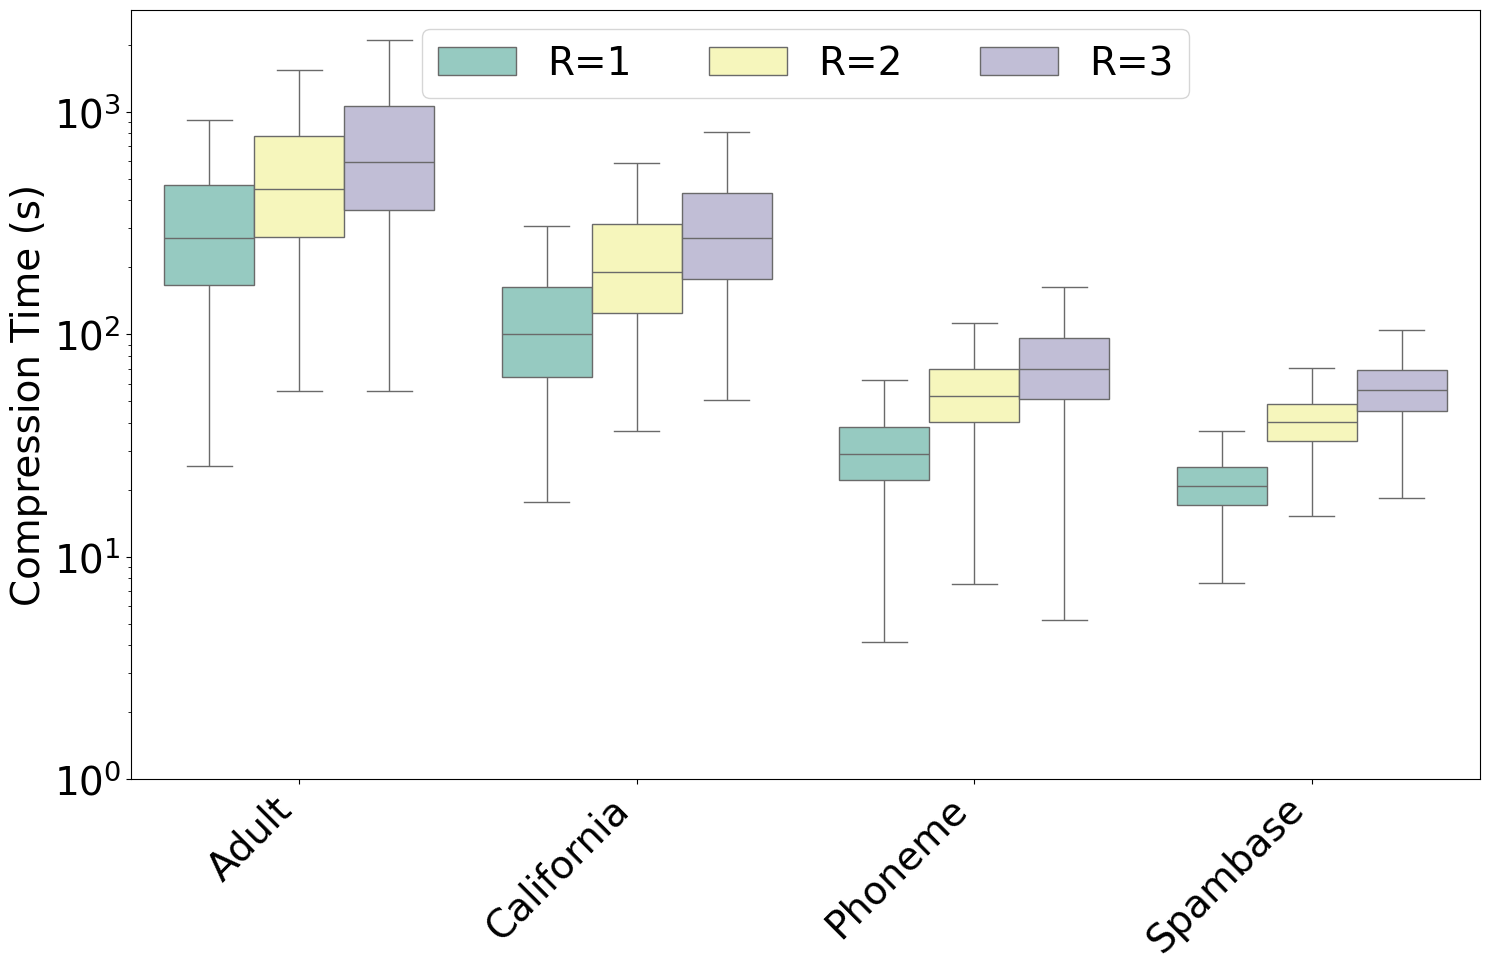

In [ ]:
# Figure A11
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the data for the required max_rounds values
df_filtered = df_sensitivity[df_sensitivity['max_rounds'].isin([1, 2, 3])]

# Order datasets alphabetically
df_filtered['dataset'] = pd.Categorical(df_filtered['dataset'], categories=sorted(df_filtered['dataset'].unique()), ordered=True)

# Create a boxplot
plt.figure(figsize=(15, 10))
ax = sns.boxplot(x='dataset', y='compr_time', hue='max_rounds', data=df_filtered, palette='Set3', showfliers=False)

# Customize the plot
plt.xticks(rotation=45, ha='right', fontsize=28)
plt.yticks(fontsize=28)
plt.ylabel('Compression Time (s)', fontsize=28)
plt.yscale('log')

# Create custom legend handles and labels
handles, _ = ax.get_legend_handles_labels()
labels = ['R=1', 'R=2', 'R=3']
plt.legend(handles, labels, fontsize=28, loc='upper center', ncol=3)
plt.tight_layout()

# Show the plot

# Remove the very small dataset at the bottom of the figure
ax.set_ylim(bottom=1)  # Set the lower limit of the y-axis to 1 to remove very small values

# Remove the 'dataset' label at the bottom of the figure
ax.set_xlabel('')  # Clear the x-axis label
plt.savefig('plots/compression_time_increasing_rounds.pdf')
plt.show()


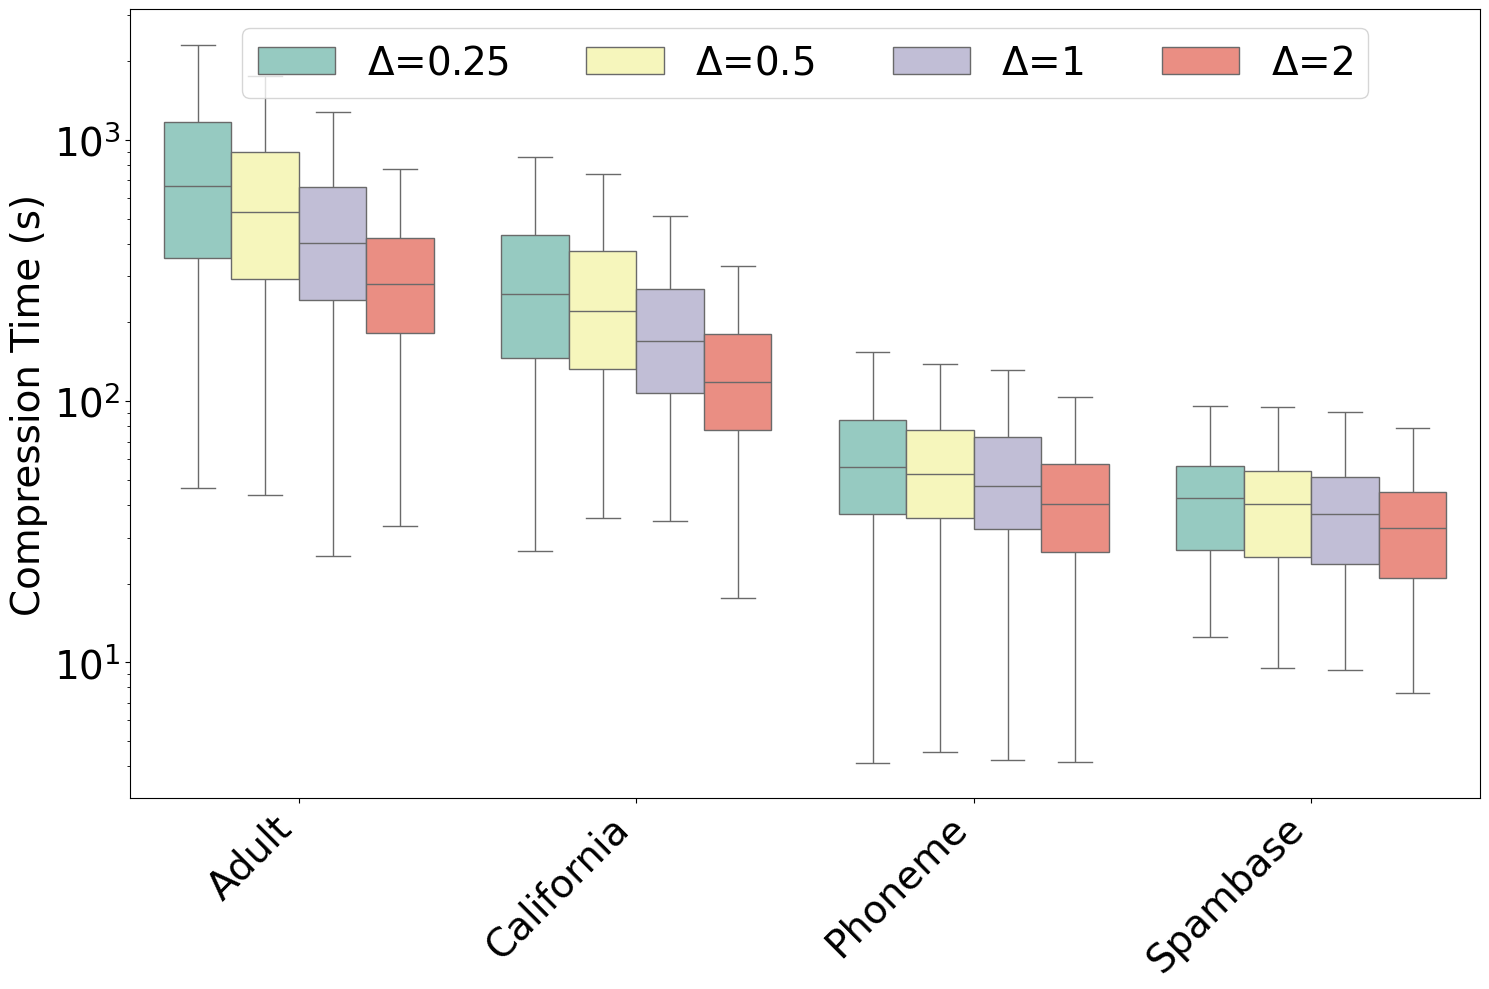

In [ ]:
# Figure A10
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the data for the required max_rounds values
df_filtered = df_sensitivity[df_sensitivity['abserr'].isin([0.0025, 0.005, 0.01, 0.02])]

# Order datasets alphabetically
df_filtered['dataset'] = pd.Categorical(df_filtered['dataset'], categories=sorted(df_filtered['dataset'].unique()), ordered=True)

# Create a boxplot
plt.figure(figsize=(15, 10))
ax = sns.boxplot(x='dataset', y='compr_time', hue='abserr', data=df_filtered, palette='Set3', showfliers=False)

# Customize the plot
plt.xticks(rotation=45, ha='right', fontsize=28)
plt.yticks(fontsize=28)
plt.ylabel('Compression Time (s)', fontsize=28)
plt.yscale('log')

# Remove the 'dataset' label at the bottom of the figure
ax.set_xlabel('')  # Clear the x-axis label

# Create custom legend handles and labels
handles, _ = ax.get_legend_handles_labels()
labels = [r'$\Delta$=0.25', r'$\Delta$=0.5', r'$\Delta$=1', r'$\Delta$=2']
plt.legend(handles, labels, fontsize=28, loc='upper center', ncol=4)
plt.tight_layout()

# Show the plot
plt.savefig('plots/compression_time_increasing_delta.pdf')